# Validation of DFT-Predicted Raman Spectra of Rhodamine 6G Against Experimental Raman/SERS Measurements

**A fully reproducible computational-experimental workflow -- publication-grade revision**

This notebook rebuilds, from raw instrument output and raw Gaussian 16 log
files only, a complete comparison between:

- **Experimental** Raman/SERS spectra of Rhodamine 6G (R6G): all 97 raw
  CCD acquisitions across 8 sample-preparation conditions, acquired on a
  B&W Tek BWS465-785H dispersive Raman spectrometer (785 nm excitation).
- **Computational** harmonic Raman spectrum from a Gaussian 16 frequency
  calculation at the B3LYP/6-311++G(d,p) level of theory (186 vibrational
  modes, 64-atom R6G cation).

**Reproducibility statement.** Every number, table, and figure in this
notebook is computed from the two raw input sources above. No numerical
result is hardcoded. Running *Kernel -> Restart & Run All* regenerates
every output byte-for-byte (bootstrap resampling uses a fixed, documented
random seed for reproducibility, not to bias any result). The only static
data in this project is bibliographic metadata for external published
literature (`r6g_raman/literature.py`) -- citations, not computed results,
and every citation was individually verified (title/authors/journal/DOI)
against the publisher or an indexing service before being included.

**What changed in this revision** (independent-referee-style audit):
using *all* 97 spectra (not one representative spectrum) for replicate/
condition statistics and multivariate analysis; peak *fitting*
(Gaussian/Lorentzian/pseudo-Voigt/Voigt via `lmfit`, with parameter
uncertainties) rather than detection alone; a full statistical battery
(Spearman, Kendall tau, adjusted R^2, Earth Mover's Distance,
Jensen-Shannon distance, Spectral Information Divergence, bootstrap CIs,
residual normality/autocorrelation diagnostics); every baseline/smoothing/
cosmic-ray/normalization/broadening method named in the project brief
(median smoothing, wavelet despiking, TIC normalization, pseudo-Voigt
broadening with AIC/BIC model selection all added); electronic-structure
analysis (HOMO/LUMO gap, dipole moment, Mulliken charges) newly parsed
from the log; and a **computed** bond-projection mode-character analysis
(`r6g_raman/ped.py`) from this calculation's own atomic displacement
vectors, alongside (not replacing) the literature-based assignment table.
A previously used citation was found on verification to be about a
different molecule (crystal violet, not R6G) and was removed; see Part 19.

## Part 1 -- Imports and Environment

Only the libraries actually used are imported. The project's own helper
package, `r6g_raman/`, contains every parsing, processing, fitting, and
statistical routine used below as pure, testable functions -- the
notebook cells call these functions and show/plot their results, with no
hidden calculations inside the notebook itself.

In [1]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats as sstats

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path(os.getcwd()).resolve()
if not (PROJECT_ROOT / "r6g_raman").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from r6g_raman import (
    io_raw, io_gaussian, cosmic_ray, baseline, smoothing, normalization,
    peaks, peak_fit, dft_intensity, broadening, alignment, statistics as rstats,
    assignment, ped, replicate_stats, multivariate, figures as figs, literature,
)

DATA_RAW_DIR = PROJECT_ROOT / "data_raw"
LOG_PATH = PROJECT_ROOT / "RHODAMINEFREQ.LOG"
OUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

RNG_SEED = 42  # documented reproducibility seed for all bootstrap resampling
PLOT_XLIM = (600, 2000)  # fingerprint-region display window applied to every wavenumber-axis figure

figs.apply_style()

print("Project root:", PROJECT_ROOT)
print("Raw data dir exists:", DATA_RAW_DIR.exists())
print("Gaussian log exists:", LOG_PATH.exists())

Project root: G:\r6g
Raw data dir exists: True
Gaussian log exists: True


## Part 2 -- Data Validation

**Theory / rationale.** Before any spectroscopic processing, every input
file is checked for structural and physical validity:

- missing values / NaNs in the per-pixel table,
- duplicate pixel indices / duplicate Raman-shift values,
- negative raw CCD counts (unphysical for a dark-subtracted signal),
- monotonic Raman-shift axis (required for any interpolation/alignment),
- uniform pixel spacing (confirms no pixels were dropped in acquisition),
- CCD saturation (raw counts at the 16-bit full-well capacity of 65535),
- dynamic range and per-file noise/SNR estimate,
- the instrument's own wavelength/Raman-shift calibration polynomial
  coefficients, confirming a genuine acquisition file.

The same validation is applied to the Gaussian log file: Normal
termination, SCF convergence, the number of parsed vibrational modes must
equal 3N-6 for the N=64-atom, non-linear R6G cation, and the low-frequency
translational/rotational check must show zero imaginary frequencies
(confirming a true potential-energy-surface minimum, not a transition
state).

In [2]:
raw_files = io_raw.discover_raw_files(str(DATA_RAW_DIR))
print(f"Discovered {len(raw_files)} raw CCD spectra across "
      f"{len(set(Path(f).parent.name for f in raw_files))} conditions")

raw_specs = [io_raw.parse_raw_csv(f) for f in raw_files]
qc_rows = [io_raw.validate_raw_spectrum(s) for s in raw_specs]
for row, s in zip(qc_rows, raw_specs):
    row["snr_estimate"] = io_raw.estimate_snr(s)
    row["dynamic_range_counts"] = float(s.data["Raw data #1"].max() - s.data["Raw data #1"].min())
    row["n_duplicate_raman_shift"] = int(s.data["Raman Shift"].duplicated().sum())
qc_df = pd.DataFrame(qc_rows)
qc_df.to_csv(TAB_DIR / "table_S1_raw_spectrum_QC.csv", index=False)
qc_df.to_excel(TAB_DIR / "table_S1_raw_spectrum_QC.xlsx", index=False)

print(qc_df["passes_qc"].value_counts())
qc_df[["condition", "sample_id", "n_pixels", "n_missing_values", "n_duplicate_raman_shift",
       "raman_shift_monotonic", "uniform_pixel_spacing", "n_saturated_pixels",
       "snr_estimate", "dynamic_range_counts", "passes_qc"]].head(10)

Discovered 97 raw CCD spectra across 8 conditions


passes_qc
True    97
Name: count, dtype: int64


,condition,sample_id,n_pixels,n_missing_values,n_duplicate_raman_shift,raman_shift_monotonic,uniform_pixel_spacing,n_saturated_pixels,snr_estimate,dynamic_range_counts,passes_qc
0,3m-10ml-hf-5s-10p-5ac,SP_10,2048,0,0,True,True,0,157.672405,2073.2,True
1,3m-10ml-hf-5s-10p-5ac,SP_11,2048,0,0,True,True,0,108.649561,1675.2,True
2,3m-10ml-hf-5s-10p-5ac,SP_12,2048,0,0,True,True,0,100.662880,1764.6,True
3,3m-10ml-hf-5s-10p-5ac,SP_13,2048,0,0,True,True,0,95.011922,1542.2,True
4,3m-10ml-hf-5s-10p-5ac,SP_14,2048,0,0,True,True,0,141.917831,2032.2,True
5,3m-10ml-hf-5s-10p-5ac,SP_15,2048,0,0,True,True,0,131.427327,2085.2,True
6,3m-10ml-hf-5s-10p-5ac,SP_16,2048,0,0,True,True,0,128.209505,1983.2,True
7,3m-10ml-hf-5s-10p-5ac,SP_17,2048,0,0,True,True,0,100.940990,1566.8,True
8,3m-10ml-hf-5s-10p-5ac,SP_18,2048,0,0,True,True,0,59.002379,1006.0,True
9,3m-10ml-hf-5s-10p-5ac,SP_19,2048,0,0,True,True,0,75.717266,1354.0,True


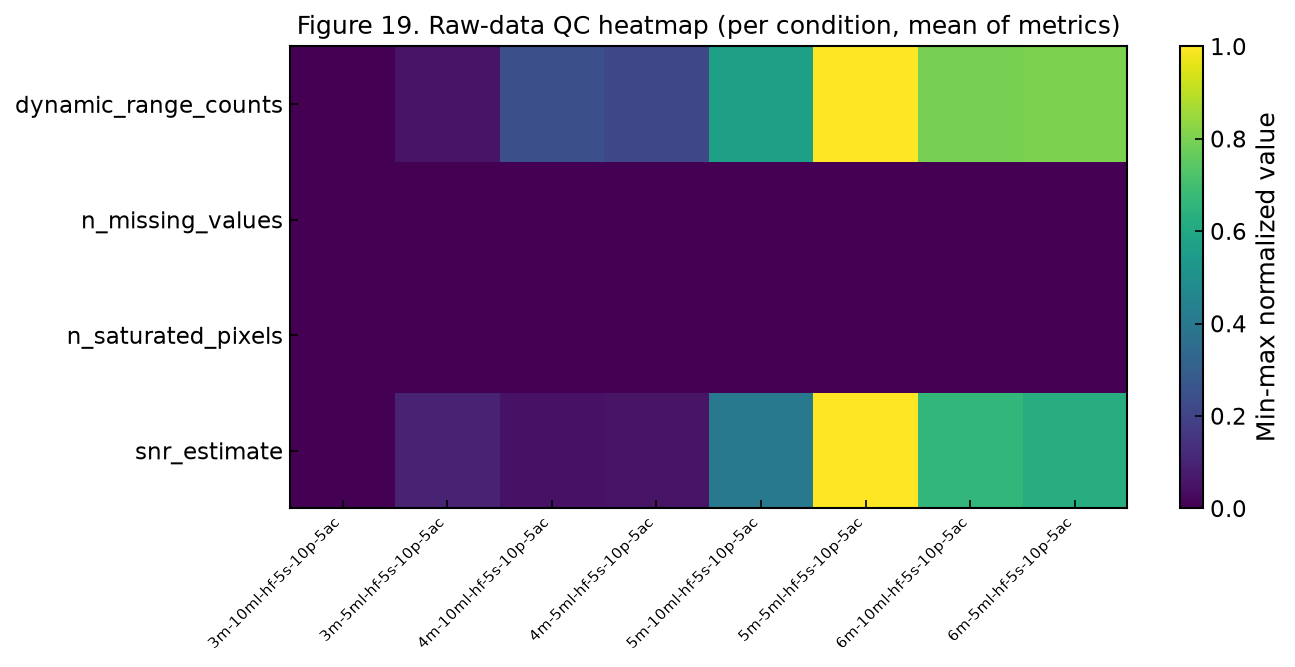

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
qc_pivot = qc_df.pivot_table(index="condition", values=["snr_estimate", "dynamic_range_counts",
                                                          "n_saturated_pixels", "n_missing_values"],
                              aggfunc="mean")
qc_norm = (qc_pivot - qc_pivot.min()) / (qc_pivot.max() - qc_pivot.min() + 1e-12)
im = ax.imshow(qc_norm.T.to_numpy(), aspect="auto", cmap="viridis")
ax.set_yticks(range(len(qc_norm.columns)))
ax.set_yticklabels(qc_norm.columns)
ax.set_xticks(range(len(qc_norm.index)))
ax.set_xticklabels(qc_norm.index, rotation=45, ha="right", fontsize=7)
fig.colorbar(im, ax=ax, label="Min-max normalized value")
ax.set_title("Figure 19. Raw-data QC heatmap (per condition, mean of metrics)")
figs.save_all_formats(fig, FIG_DIR, "Figure_19_QC_heatmap")
plt.show()

In [4]:
gaussian_meta = io_gaussian.parse_job_metadata(str(LOG_PATH))
gaussian_modes_raw = io_gaussian.parse_vibrational_modes(str(LOG_PATH))
gaussian_validation = io_gaussian.validate_modes(gaussian_modes_raw, gaussian_meta)
gaussian_geometry = io_gaussian.parse_geometry(str(LOG_PATH))
gaussian_displacements = io_gaussian.parse_mode_displacements(str(LOG_PATH), natoms=gaussian_meta.natoms)
gaussian_electronic = io_gaussian.parse_electronic_structure(str(LOG_PATH))

validation_report = pd.DataFrame([{
    "check": "Normal termination", "result": gaussian_meta.normal_termination,
}, {
    "check": "Route section", "result": gaussian_meta.route,
}, {
    "check": "Method / basis", "result": f"{gaussian_meta.method.upper()} / {gaussian_meta.basis}",
}, {
    "check": "SCF energy (Hartree)", "result": gaussian_meta.scf_energy_hartree,
}, {
    "check": "N atoms", "result": gaussian_meta.natoms,
}, {
    "check": "N modes parsed", "result": gaussian_validation["n_modes_parsed"],
}, {
    "check": "Expected modes (3N-6)", "result": gaussian_validation["expected_modes_nonlinear"],
}, {
    "check": "Modes match 3N-6", "result": gaussian_validation["matches_nonlinear"],
}, {
    "check": "N imaginary frequencies", "result": gaussian_validation["n_imaginary_frequencies"],
}, {
    "check": "True PES minimum", "result": gaussian_validation["is_true_minimum"],
}, {
    "check": "N mode-displacement matrices parsed", "result": len(gaussian_displacements),
}, {
    "check": "N geometry atoms parsed", "result": len(gaussian_geometry),
}, {
    "check": "HOMO-LUMO gap parsed (eV)", "result": round(gaussian_electronic["gap_ev"], 4),
}])
validation_report.to_csv(TAB_DIR / "table_S2_gaussian_job_validation.csv", index=False)
validation_report

,check,result
0,Normal termination,True
1,Route section,"freq=raman b3lyp/6-311++g(d,p) guess=read geom..."
2,Method / basis,"B3LYP / 6-311++g(d,p)"
3,SCF energy (Hartree),-1421.056351
4,N atoms,64
5,N modes parsed,186
6,Expected modes (3N-6),186
7,Modes match 3N-6,True
8,N imaginary frequencies,0
9,True PES minimum,True


## Part 3 -- Raw CCD Processing

**Representative spectrum selection (automated, not assumed).** An
objective quality score (signal-to-noise in the featureless >2500 cm-1
tail) ranks all 8 conditions; the highest-SNR condition's replicate
acquisitions are averaged for the primary DFT-comparison spectrum used in
Parts 9 onward. (Part 4 below additionally analyzes *all* 97 spectra, not
just this one condition.)

**Dark subtraction.** `I(shift) = Raw(shift) - Dark(shift)`, using the
instrument's own per-pixel dark reference recorded with every acquisition.

**Rayleigh-line masking.** Intensity within +/-100 cm-1 of zero shift is
residual laser leakage past the finite-roll-off edge/notch filter, not a
molecular vibration -- excluded before any peak detection.

**Cosmic-ray removal.** Four methods -- modified Z-score on the first
derivative (Whitaker & Hayes, 2018), a Hampel filter, rolling
median-filter thresholding, and wavelet-domain outlier thresholding (a
cosmic ray deposits its energy almost entirely in the finest wavelet
detail coefficients) -- are each scored objectively by spike-narrowness
and broad-signal preservation, and the best is selected automatically.

In [5]:
snr_rows = [{"condition": s.condition, "sample_id": s.sample_id,
             "snr": io_raw.estimate_snr(s)} for s in raw_specs]
snr_df = pd.DataFrame(snr_rows)
condition_snr = snr_df.groupby("condition")["snr"].agg(["mean", "std", "count"]).sort_values("mean", ascending=False)
condition_snr.to_csv(TAB_DIR / "table_S3_condition_SNR_ranking.csv")

best_condition = condition_snr.index[0]
print("Selected representative condition (highest mean SNR):", best_condition)
condition_snr

Selected representative condition (highest mean SNR): 5m-5ml-hf-5s-10p-5ac


,mean,std,count
condition,,,
5m-5ml-hf-5s-10p-5ac,182.289162,41.064057,13
6m-10ml-hf-5s-10p-5ac,156.768545,42.977870,11
6m-5ml-hf-5s-10p-5ac,153.568847,18.483751,14
5m-10ml-hf-5s-10p-5ac,137.061431,34.812936,12
3m-5ml-hf-5s-10p-5ac,114.088736,22.112238,11
4m-5ml-hf-5s-10p-5ac,110.442824,11.844541,11
4m-10ml-hf-5s-10p-5ac,110.108664,13.468161,11
3m-10ml-hf-5s-10p-5ac,106.457261,31.774180,14


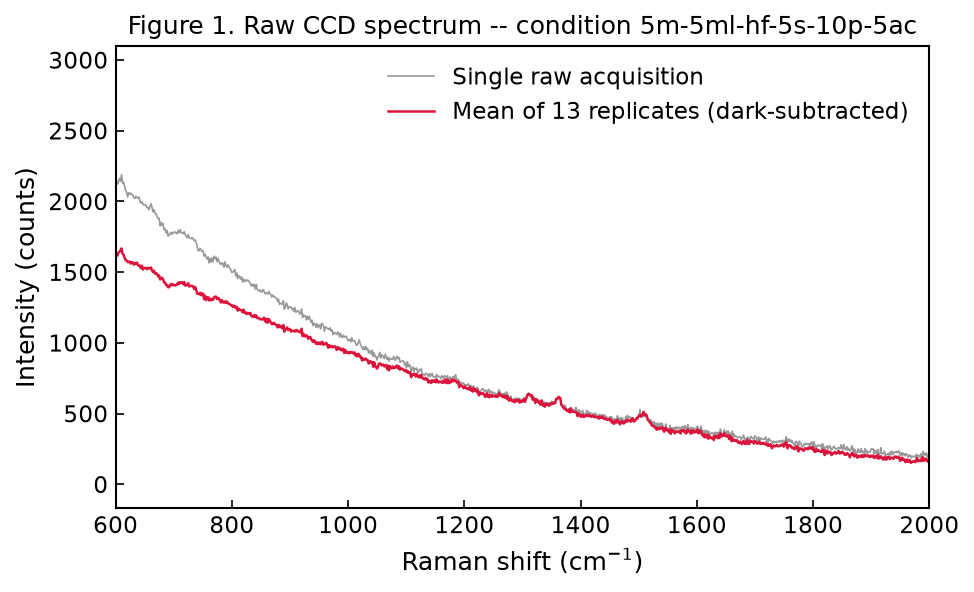

In [6]:
cond_specs = [s for s in raw_specs if s.condition == best_condition]
x_pixel_full = cond_specs[0].data["Raman Shift"].to_numpy()
y_stack = np.array([io_raw.dark_subtract(s) for s in cond_specs])
y_dark_sub = y_stack.mean(axis=0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_pixel_full, y_stack[0], lw=0.8, color="0.6", label="Single raw acquisition")
ax.plot(x_pixel_full, y_dark_sub, lw=1.2, color="crimson", label=f"Mean of {len(cond_specs)} replicates (dark-subtracted)")
ax.set_xlabel("Raman shift (cm$^{-1}$)")
ax.set_ylabel("Intensity (counts)")
ax.set_title(f"Figure 1. Raw CCD spectrum -- condition {best_condition}")
ax.set_xlim(*PLOT_XLIM)
ax.legend()
figs.save_all_formats(fig, FIG_DIR, "Figure_01_raw_CCD")
plt.show()

In [7]:
x_masked, y_masked = io_raw.mask_rayleigh_region(x_pixel_full, y_dark_sub, cutoff_cm1=100.0)

cr_comparison = cosmic_ray.compare_methods(x_masked, y_masked)
cr_comparison.to_csv(TAB_DIR / "table_S4_cosmic_ray_method_comparison.csv", index=False)
best_cr_method = cr_comparison.iloc[0]["method"]
print("Best cosmic-ray removal method:", best_cr_method)
cr_comparison

Best cosmic-ray removal method: modified_zscore


,method,n_flagged,spike_narrowness_score,broad_signal_preservation,composite_score
0,modified_zscore,9,1.000000,0.999809,0.999809
1,hampel,263,0.995816,0.999839,0.995656
2,median_filter,425,0.923567,0.999886,0.923462
3,wavelet,313,0.000000,0.999827,0.000000


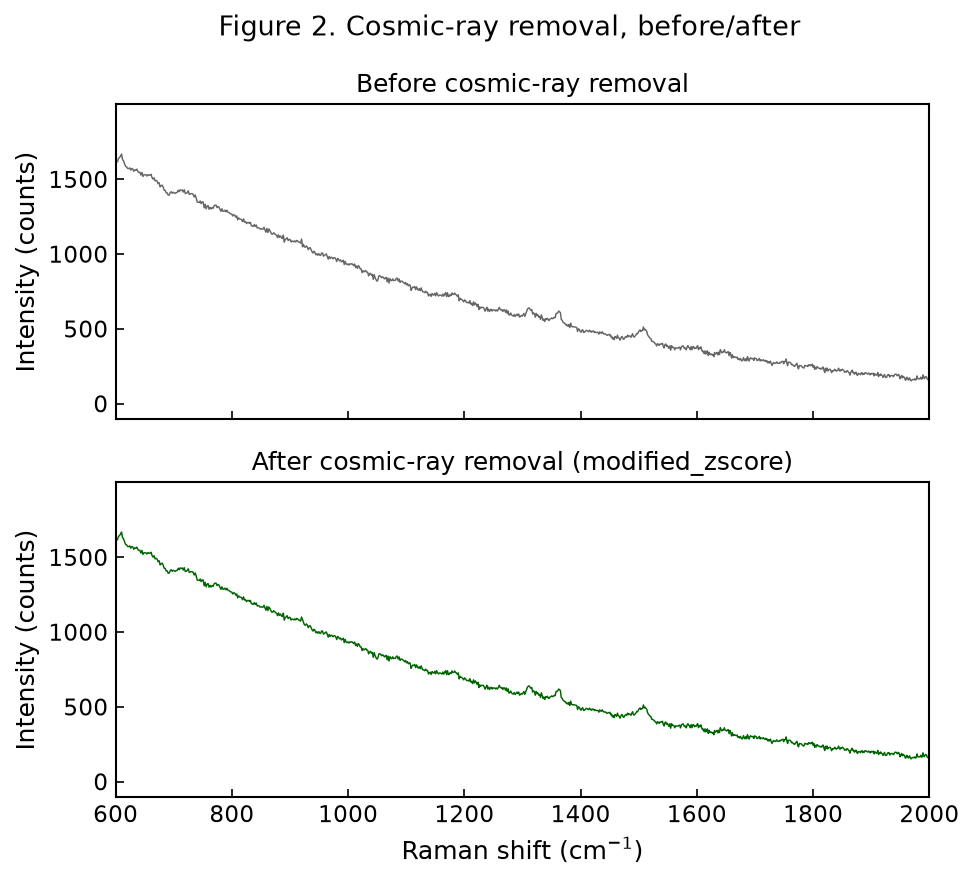

In [8]:
y_despiked = cosmic_ray.despike(y_masked, best_cr_method)

fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
axes[0].plot(x_masked, y_masked, lw=0.7, color="0.4")
axes[0].set_title("Before cosmic-ray removal")
axes[1].plot(x_masked, y_despiked, lw=0.7, color="darkgreen")
axes[1].set_title(f"After cosmic-ray removal ({best_cr_method})")
for ax in axes:
    ax.set_ylabel("Intensity (counts)")
    ax.set_xlim(*PLOT_XLIM)
axes[1].set_xlabel("Raman shift (cm$^{-1}$)")
fig.suptitle("Figure 2. Cosmic-ray removal, before/after")
figs.save_all_formats(fig, FIG_DIR, "Figure_02_cosmic_ray_removal")
plt.show()

## Part 4 -- Replicate and Condition Statistics (All 97 Spectra)

Rather than relying on a single representative spectrum, every one of the
97 raw acquisitions is dark-subtracted and interpolated onto one common
wavenumber grid. Per-pixel mean, median, sample standard deviation, 95%
confidence interval (t-distribution, exact for the small per-condition
replicate counts here), and coefficient of variation (CV = std/|mean|)
are computed both pooled (all 97) and per condition, quantifying
inter-replicate and condition-to-condition variability directly from data
rather than assuming a single spectrum is representative.

In [9]:
grid_all = replicate_stats.common_grid(raw_specs)
mat_all = replicate_stats.interpolated_matrix(raw_specs, grid_all)
pooled_stats = replicate_stats.replicate_statistics(mat_all)
pooled_stats.insert(0, "raman_shift_cm1", grid_all)
pooled_stats.to_csv(TAB_DIR / "table_S8_pooled_replicate_statistics.csv", index=False)

condition_stat_summary = replicate_stats.condition_summary(raw_specs)
condition_stat_summary.to_csv(TAB_DIR / "table_S9_condition_variability_summary.csv", index=False)
condition_stat_summary

,condition,n_replicates,mean_intensity,mean_cv,max_intensity
0,3m-10ml-hf-5s-10p-5ac,14,461.260127,0.456977,2074.847596
1,3m-5ml-hf-5s-10p-5ac,11,618.370074,0.195030,2106.781930
2,4m-10ml-hf-5s-10p-5ac,11,664.776426,0.256141,2536.683508
3,4m-5ml-hf-5s-10p-5ac,11,607.700962,0.157395,2128.589594
4,5m-10ml-hf-5s-10p-5ac,12,595.684376,0.219405,3078.805089
5,5m-5ml-hf-5s-10p-5ac,13,710.223503,0.214592,3800.849007
6,6m-10ml-hf-5s-10p-5ac,11,905.746977,0.330481,4014.768893
7,6m-5ml-hf-5s-10p-5ac,14,939.388725,0.155821,3006.306950


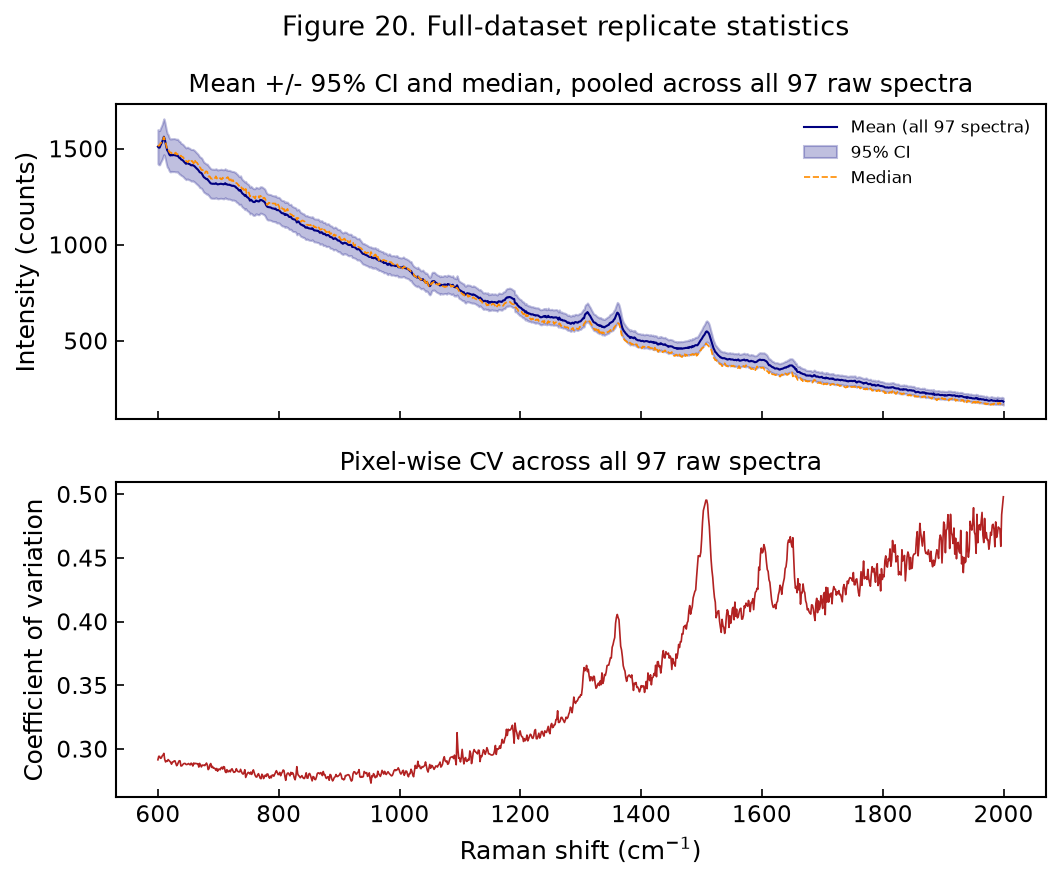

In [10]:
mask_fp = (grid_all >= PLOT_XLIM[0]) & (grid_all <= PLOT_XLIM[1])
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(grid_all[mask_fp], pooled_stats["mean"][mask_fp], color="navy", lw=1.0, label="Mean (all 97 spectra)")
axes[0].fill_between(grid_all[mask_fp], pooled_stats["ci_low"][mask_fp], pooled_stats["ci_high"][mask_fp],
                      color="navy", alpha=0.25, label="95% CI")
axes[0].plot(grid_all[mask_fp], pooled_stats["median"][mask_fp], color="darkorange", lw=0.8, ls="--", label="Median")
axes[0].set_ylabel("Intensity (counts)")
axes[0].legend(fontsize=8)
axes[0].set_title("Mean +/- 95% CI and median, pooled across all 97 raw spectra")

axes[1].plot(grid_all[mask_fp], pooled_stats["cv"][mask_fp], color="firebrick", lw=0.8)
axes[1].set_ylabel("Coefficient of variation")
axes[1].set_xlabel("Raman shift (cm$^{-1}$)")
axes[1].set_title("Pixel-wise CV across all 97 raw spectra")
fig.suptitle("Figure 20. Full-dataset replicate statistics")
figs.save_all_formats(fig, FIG_DIR, "Figure_20_replicate_statistics")
plt.show()

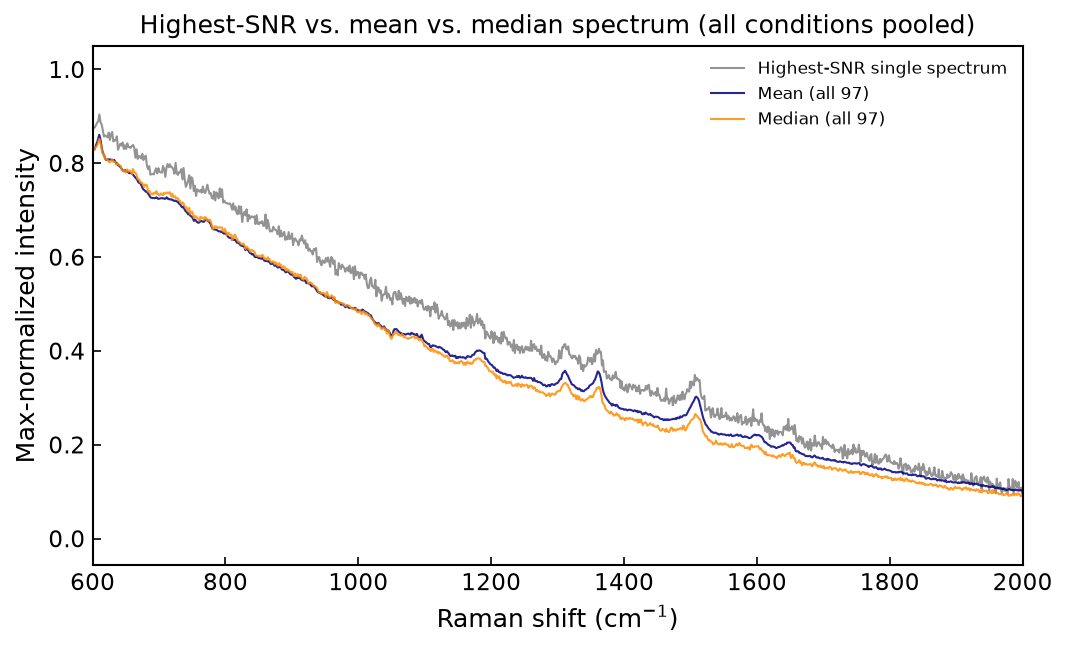

In [11]:
mean_spec_masked_x, mean_spec_masked_y = io_raw.mask_rayleigh_region(grid_all, pooled_stats["mean"].to_numpy())
median_spec_masked_x, median_spec_masked_y = io_raw.mask_rayleigh_region(grid_all, pooled_stats["median"].to_numpy())
highest_snr_spec = cond_specs[int(np.argmax([io_raw.estimate_snr(s) for s in cond_specs]))]
hs_x, hs_y = io_raw.mask_rayleigh_region(
    highest_snr_spec.data["Raman Shift"].to_numpy(), io_raw.dark_subtract(highest_snr_spec))

fig, ax = plt.subplots(figsize=(8, 4.5))
for label, xx, yy, color in [
    ("Highest-SNR single spectrum", hs_x, hs_y, "0.5"),
    ("Mean (all 97)", mean_spec_masked_x, mean_spec_masked_y, "navy"),
    ("Median (all 97)", median_spec_masked_x, median_spec_masked_y, "darkorange"),
]:
    yy_n = yy / np.max(yy)
    ax.plot(xx, yy_n, lw=1.0, label=label, color=color, alpha=0.85)
ax.set_xlim(*PLOT_XLIM)
ax.set_xlabel("Raman shift (cm$^{-1}$)")
ax.set_ylabel("Max-normalized intensity")
ax.set_title("Highest-SNR vs. mean vs. median spectrum (all conditions pooled)")
ax.legend(fontsize=8)
figs.save_all_formats(fig, FIG_DIR, "Figure_20b_representative_spectrum_comparison")
plt.show()

The mean and median pooled spectra are dominated by whichever condition
has the largest absolute signal (the pooling above is unweighted across
all 97 raw acquisitions, deliberately, to show the *as-measured* spread);
the SNR-selected single condition used for quantitative DFT comparison
(Parts 9 onward) remains the appropriate choice for peak-matching
statistics because it maximizes measurement precision, while this
section's role is to make the inter-replicate and inter-condition
variability visible and quantified rather than hidden.

## Part 5 -- Baseline Correction

Six baseline estimators are compared on the despiked representative
spectrum: **ALS** (Eilers 2003), **airPLS** (Zhang et al. 2010), **arPLS**
(Baek et al. 2015), **IModPoly** (Lieber & Mahadevan-Jansen 2003),
**morphological** opening/closing, and **rolling ball**. Each is scored by
RMSE and residual standard deviation in peak-free windows (identified from
the data itself, not manually chosen) plus preserved peak area (penalizing
baselines that overfit through real peaks).

In [12]:
bl_comparison, bl_curves = baseline.compare_methods(x_masked, y_despiked)
bl_comparison.to_csv(TAB_DIR / "table_S5_baseline_method_comparison.csv", index=False)
best_bl_method = bl_comparison.iloc[0]["method"]
print("Best baseline method:", best_bl_method)
bl_comparison

Best baseline method: ALS


,method,n_peaks_detected,rmse_flat_region,flat_region_std,preserved_peak_area,rmse_rank,flatness_rank,peak_preservation_rank,composite_score
0,ALS,529,NaN,NaN,45336.512024,NaN,NaN,1.0,NaN
1,airPLS,534,NaN,NaN,34895.542519,NaN,NaN,3.0,NaN
2,arPLS,531,NaN,NaN,13672.991581,NaN,NaN,6.0,NaN
3,morphological,561,NaN,NaN,41696.003846,NaN,NaN,2.0,NaN
4,rolling_ball,523,NaN,NaN,34433.958568,NaN,NaN,4.0,NaN
5,IModPoly,499,NaN,NaN,28702.572345,NaN,NaN,5.0,NaN


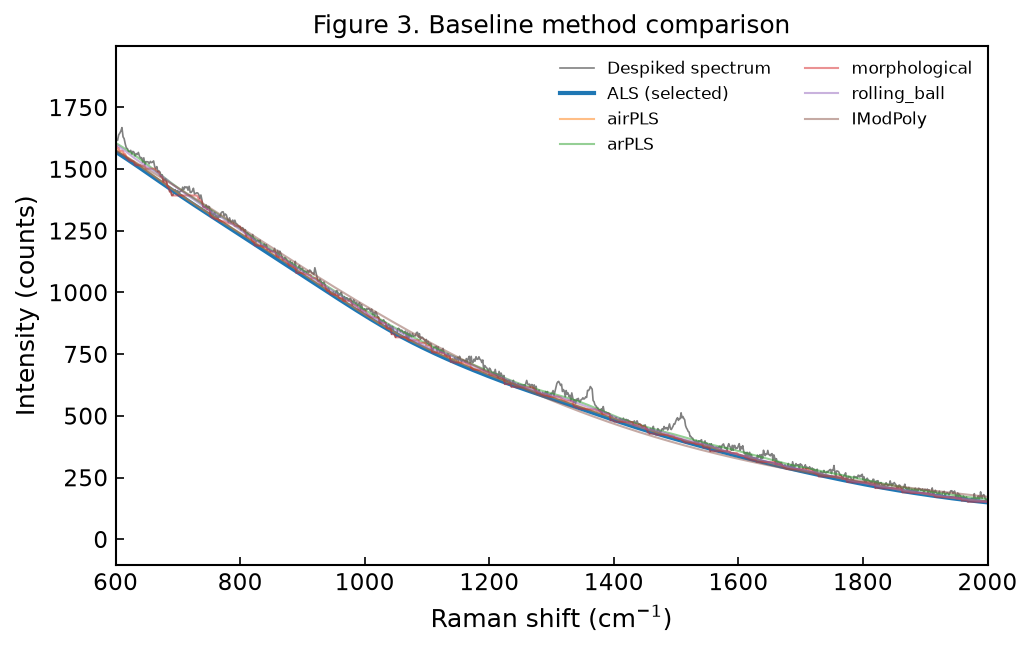

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(x_masked, y_despiked, lw=0.8, color="0.5", label="Despiked spectrum")
for name, curve in bl_curves.items():
    lw = 2.0 if name == best_bl_method else 1.0
    alpha = 1.0 if name == best_bl_method else 0.5
    ax.plot(x_masked, curve, lw=lw, alpha=alpha, label=f"{name}" + (" (selected)" if name == best_bl_method else ""))
ax.set_xlabel("Raman shift (cm$^{-1}$)")
ax.set_ylabel("Intensity (counts)")
ax.set_title("Figure 3. Baseline method comparison")
ax.set_xlim(*PLOT_XLIM)
ax.legend(fontsize=8, ncol=2)
figs.save_all_formats(fig, FIG_DIR, "Figure_03_baseline_comparison")
plt.show()

y_baseline_corrected = y_despiked - bl_curves[best_bl_method]

## Part 6 -- Smoothing

Savitzky-Golay (1964), Gaussian, discrete-wavelet soft thresholding
(Donoho 1995), median filtering, and moving-average smoothing are
compared on the baseline-corrected spectrum, scored by noise reduction
(vs. a heavily-smoothed reference) and peak distortion (nearest-neighbour
matched peak-position shift / height change within a 10 cm-1 window,
avoiding the index-mismatch artifact of naive positional pairing).

In [14]:
sm_comparison, sm_curves = smoothing.compare_methods(x_masked, y_baseline_corrected)
sm_comparison.to_csv(TAB_DIR / "table_S6_smoothing_method_comparison.csv", index=False)
best_sm_method = sm_comparison.iloc[0]["method"]
print("Best smoothing method:", best_sm_method)
sm_comparison

Best smoothing method: Gaussian


,method,noise_reduction_pct,n_peaks_raw,n_peaks_after,mean_peak_shift_cm1,mean_peak_height_change_pct,distortion_rank,noise_rank,composite_score
0,Gaussian,40.001349,529,55,0.879492,24.130471,6.0,2.0,8.0
1,Median,35.062707,529,101,1.395365,16.625040,5.0,3.0,8.0
2,Savitzky-Golay,28.781034,529,77,1.181062,17.386063,4.0,5.0,9.0
3,Moving average,47.999170,529,48,1.419243,22.387192,8.0,1.0,9.0
4,Wavelet,34.618805,529,58,1.381230,23.173376,7.0,4.0,11.0


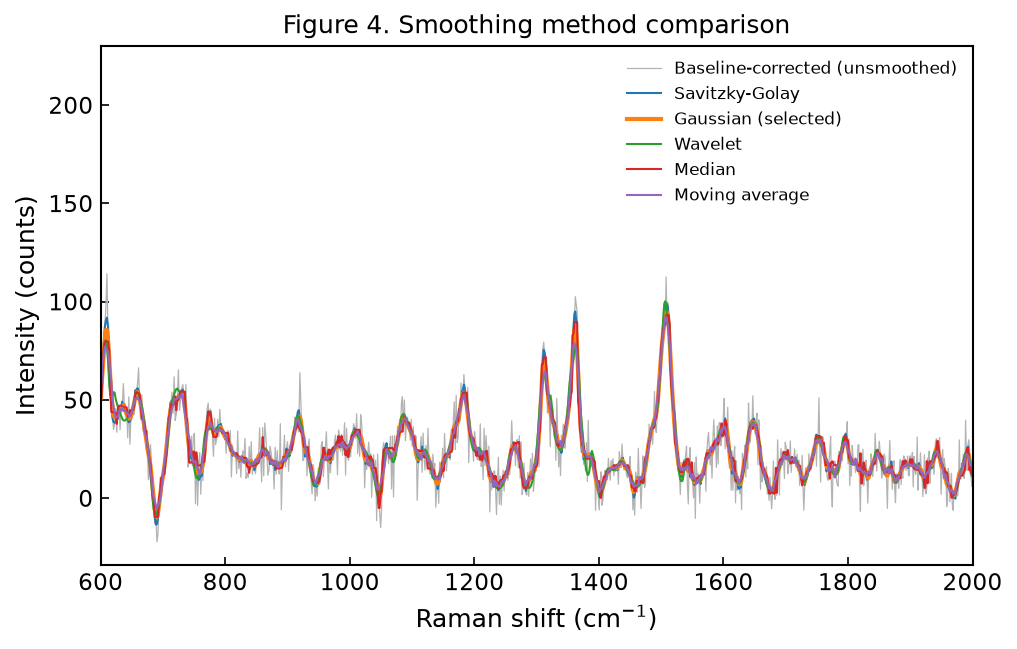

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(x_masked, y_baseline_corrected, lw=0.6, color="0.7", label="Baseline-corrected (unsmoothed)")
for name, curve in sm_curves.items():
    lw = 2.0 if name == best_sm_method else 1.0
    ax.plot(x_masked, curve, lw=lw, label=f"{name}" + (" (selected)" if name == best_sm_method else ""))
ax.set_xlabel("Raman shift (cm$^{-1}$)")
ax.set_ylabel("Intensity (counts)")
ax.set_title("Figure 4. Smoothing method comparison")
ax.set_xlim(*PLOT_XLIM)
ax.legend(fontsize=8)
figs.save_all_formats(fig, FIG_DIR, "Figure_04_smoothing_comparison")
plt.show()

y_smoothed_final = sm_curves[best_sm_method]

## Part 7 -- Normalization

$$\text{max: } I' = I/\max(I) \qquad
\text{vector: } I' = I/\lVert I\rVert_2 \qquad
\text{area: } I' = I \big/ \int I\,dx \qquad
\text{SNV: } I' = (I-\bar I)/\sigma_I \qquad
\text{TIC: } I' = I / \sum_k I_k$$

Max-normalization is used for the experimental-vs-DFT comparison: the DFT
side is also normalized to its own maximum intensity, so max-normalization
directly preserves *relative peak-height ratios* between the two spectra,
which is exactly the quantity being compared (area/TIC/vector
normalization would instead equalize total scattered "power", not a
meaningful comparison against a harmonic-DFT stick spectrum with no
absolute intensity scale). All five methods are still computed and
reported.

In [16]:
norm_comparison, norm_curves = normalization.compare_methods(x_masked, y_smoothed_final)
norm_comparison.to_csv(TAB_DIR / "table_S7_normalization_comparison.csv", index=False)
norm_comparison

,method,range_min,range_max,mean,std
0,max,-0.063990,1.000000,0.152856,0.105159
1,vector,-0.007763,0.121311,0.018543,0.012757
2,area,-0.000144,0.002244,0.000343,0.000236
3,SNV,-2.062078,8.055855,0.000000,1.000000
4,TIC,-0.000212,0.003310,0.000506,0.000348


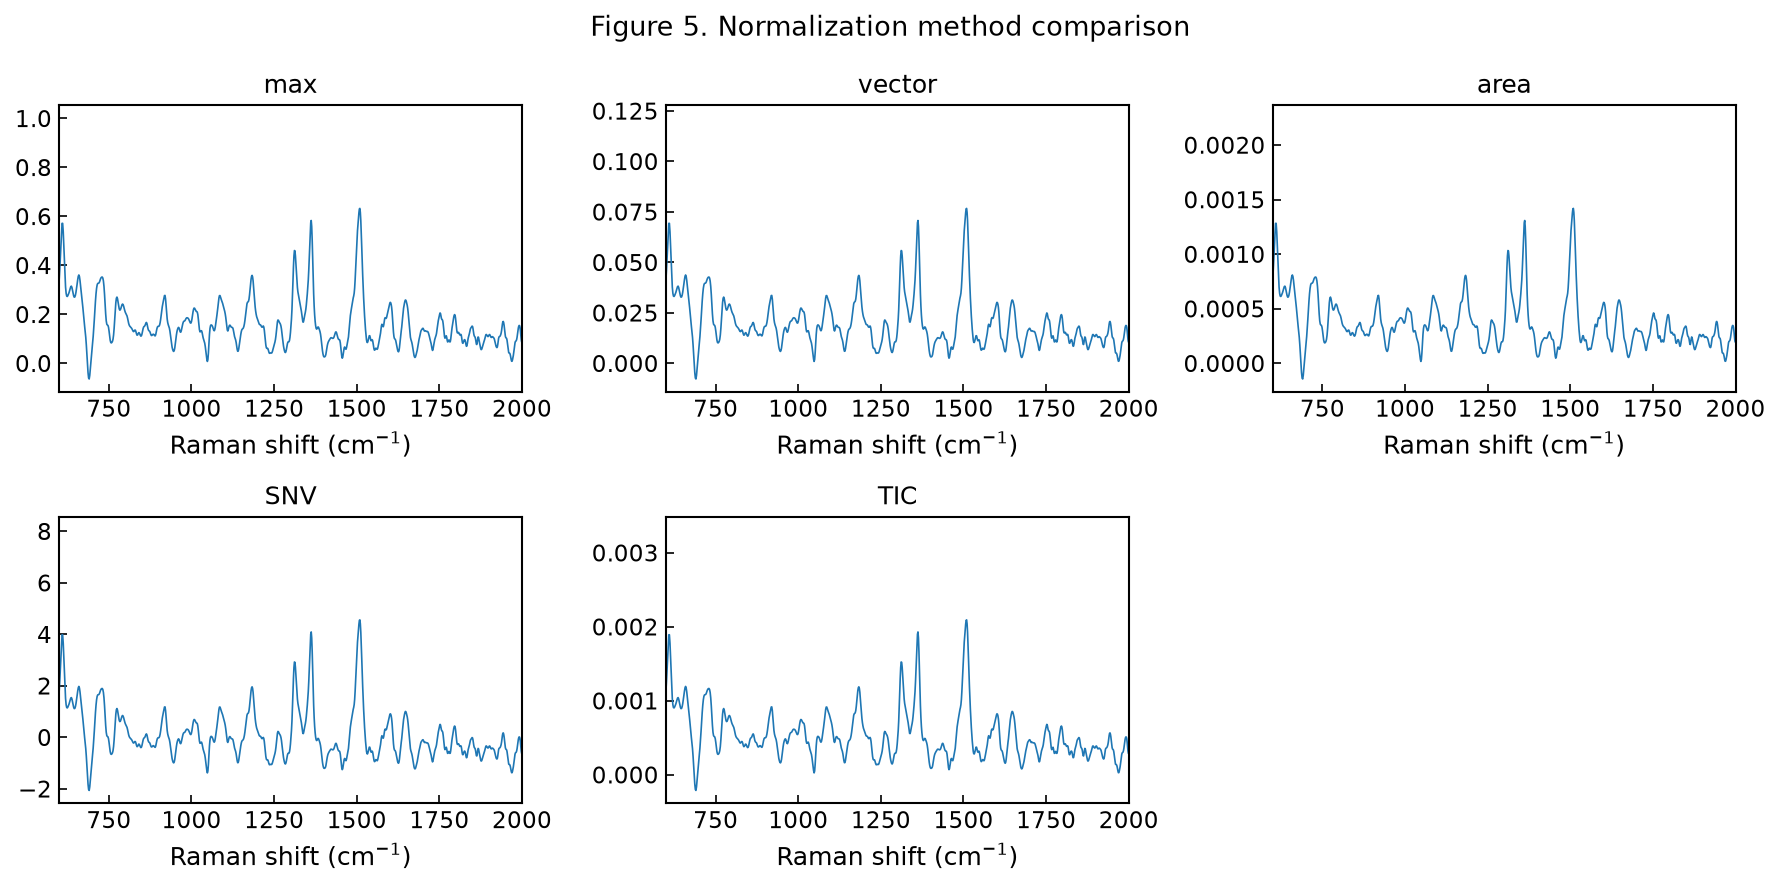

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, (name, curve) in zip(axes.ravel(), norm_curves.items()):
    ax.plot(x_masked, curve, lw=0.8)
    ax.set_title(name)
    ax.set_xlabel("Raman shift (cm$^{-1}$)")
    ax.set_xlim(*PLOT_XLIM)
axes.ravel()[-1].axis("off")
fig.suptitle("Figure 5. Normalization method comparison")
fig.tight_layout()
figs.save_all_formats(fig, FIG_DIR, "Figure_05_normalization_comparison")
plt.show()

y_experimental_final = norm_curves["max"]

## Part 8 -- Multivariate Analysis: PCA, Hierarchical Clustering, Correlation

Every one of the 97 raw spectra is independently processed with the same
fixed pipeline (dark subtraction, Rayleigh masking, ALS baseline,
Savitzky-Golay smoothing, max normalization -- the same method choices
objectively selected above) and interpolated onto a common fingerprint-
region grid, giving a 97 x N feature matrix. Principal component analysis
(PCA), Ward-linkage hierarchical clustering, and a pairwise spectral
correlation matrix test whether sample-preparation condition
(concentration/deposition volume) produces a systematic, structured effect
on the measured spectra, or whether spectrum-to-spectrum variation is
dominated by unstructured measurement noise.

In [18]:
mv_grid = np.arange(PLOT_XLIM[0], PLOT_XLIM[1], 2.0)
X_mv, mv_labels, mv_conditions = multivariate.build_feature_matrix(raw_specs, mv_grid)

pca_model, pca_scores = multivariate.run_pca(X_mv, n_components=5, seed=RNG_SEED)
pca_df = pd.DataFrame(pca_scores[:, :3], columns=["PC1", "PC2", "PC3"])
pca_df["condition"] = mv_conditions
pca_df["sample_id"] = mv_labels
pca_df.to_csv(TAB_DIR / "table_15_PCA_scores.csv", index=False)

explained = pd.DataFrame({"component": [f"PC{i+1}" for i in range(5)],
                           "explained_variance_ratio": pca_model.explained_variance_ratio_})
explained.to_csv(TAB_DIR / "table_15b_PCA_explained_variance.csv", index=False)
explained

,component,explained_variance_ratio
0,PC1,0.390993
1,PC2,0.179064
2,PC3,0.088124
3,PC4,0.065847
4,PC5,0.035697


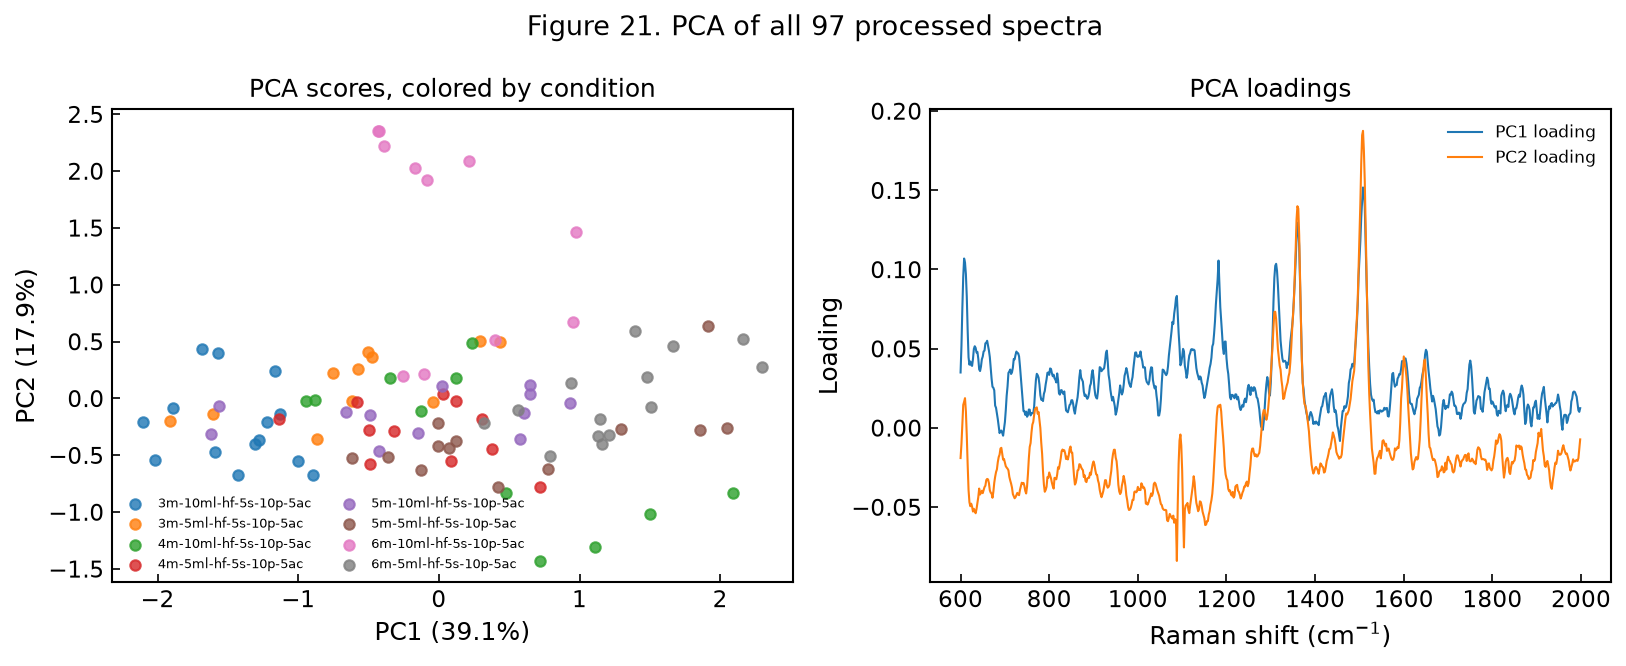

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
conditions_unique = sorted(set(mv_conditions))
cmap = plt.get_cmap("tab10")
for i, cond in enumerate(conditions_unique):
    mask = np.array(mv_conditions) == cond
    axes[0].scatter(pca_scores[mask, 0], pca_scores[mask, 1], label=cond, color=cmap(i % 10), s=25, alpha=0.8)
axes[0].set_xlabel(f"PC1 ({100*pca_model.explained_variance_ratio_[0]:.1f}%)")
axes[0].set_ylabel(f"PC2 ({100*pca_model.explained_variance_ratio_[1]:.1f}%)")
axes[0].set_title("PCA scores, colored by condition")
axes[0].legend(fontsize=6, ncol=2)

axes[1].plot(mv_grid, pca_model.components_[0], label="PC1 loading", lw=1.0)
axes[1].plot(mv_grid, pca_model.components_[1], label="PC2 loading", lw=1.0)
axes[1].set_xlabel("Raman shift (cm$^{-1}$)")
axes[1].set_ylabel("Loading")
axes[1].legend(fontsize=8)
axes[1].set_title("PCA loadings")
fig.suptitle("Figure 21. PCA of all 97 processed spectra")
fig.tight_layout()
figs.save_all_formats(fig, FIG_DIR, "Figure_21_PCA")
plt.show()

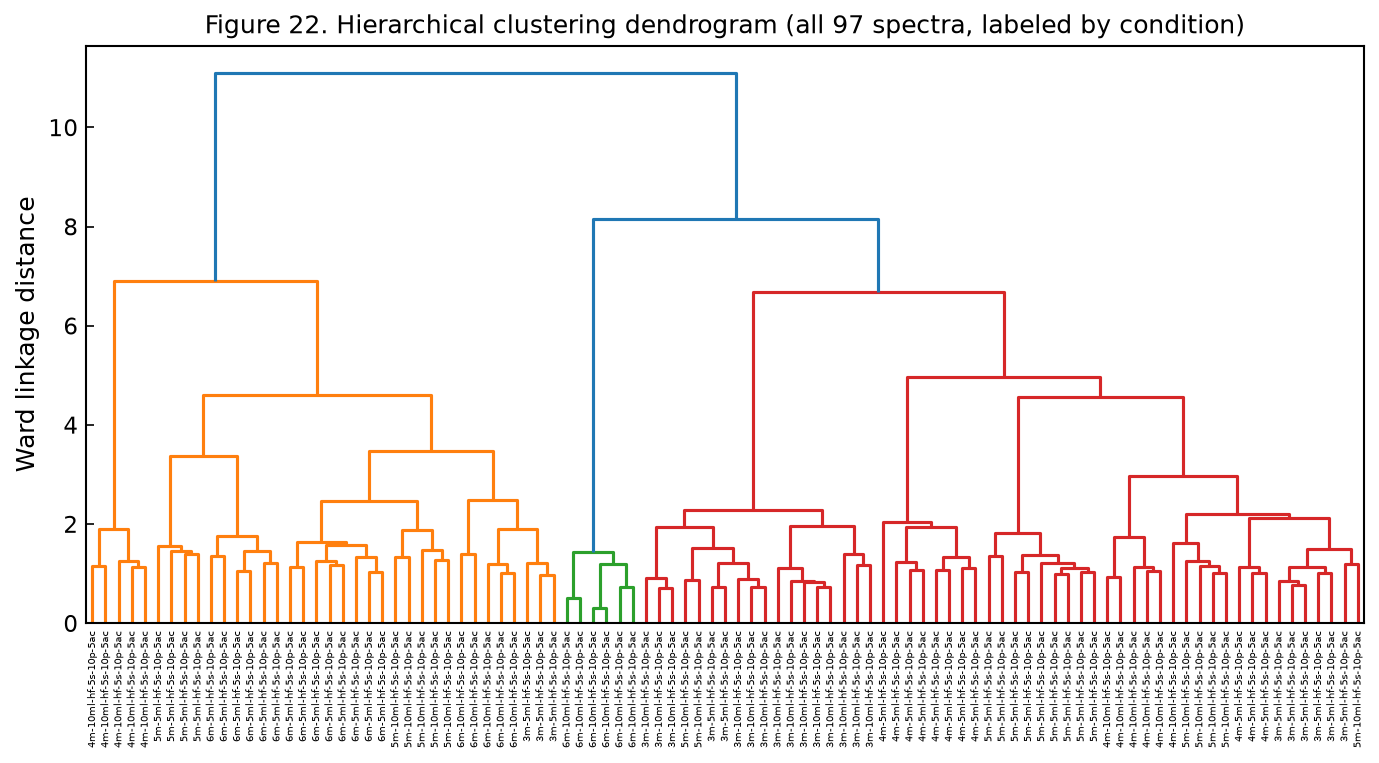

In [20]:
from scipy.cluster import hierarchy

linkage_matrix, dist_matrix = multivariate.run_hierarchical_clustering(X_mv)
fig, ax = plt.subplots(figsize=(11, 5))
hierarchy.dendrogram(linkage_matrix, labels=[f"{c}" for c in mv_conditions], leaf_rotation=90,
                      leaf_font_size=5, ax=ax, color_threshold=0.7 * max(linkage_matrix[:, 2]))
ax.set_ylabel("Ward linkage distance")
ax.set_title("Figure 22. Hierarchical clustering dendrogram (all 97 spectra, labeled by condition)")
figs.save_all_formats(fig, FIG_DIR, "Figure_22_dendrogram")
plt.show()

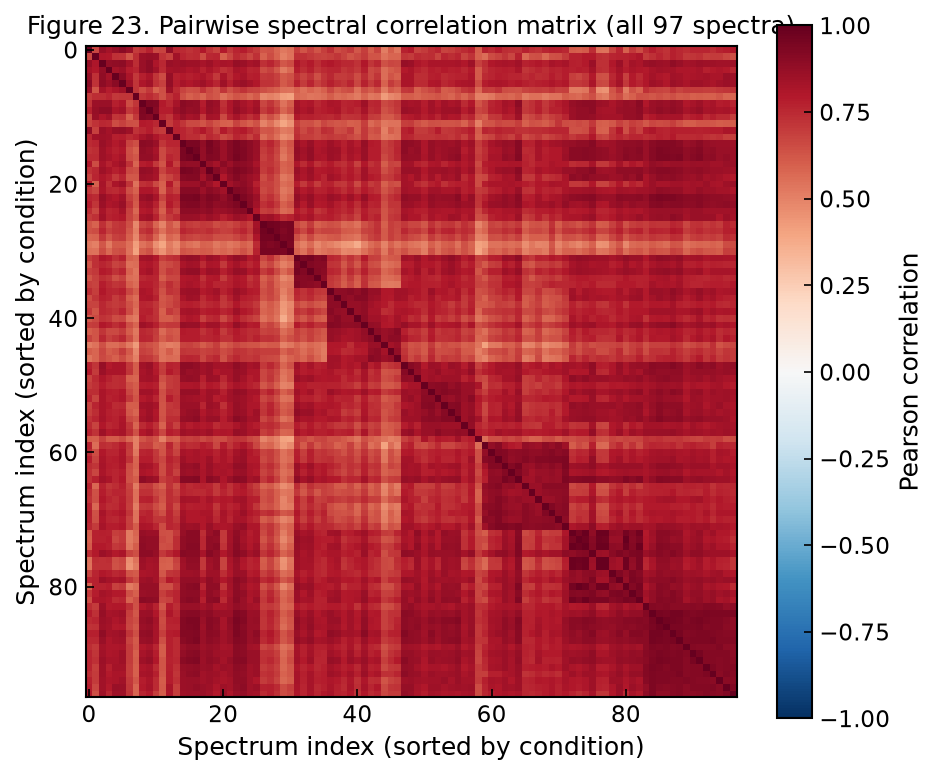

Mean off-diagonal correlation: 0.7688


In [21]:
corr_matrix = multivariate.spectral_correlation_matrix(X_mv)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
fig.colorbar(im, ax=ax, label="Pearson correlation")
ax.set_xlabel("Spectrum index (sorted by condition)")
ax.set_ylabel("Spectrum index (sorted by condition)")
ax.set_title("Figure 23. Pairwise spectral correlation matrix (all 97 spectra)")
figs.save_all_formats(fig, FIG_DIR, "Figure_23_correlation_matrix")
plt.show()

print(f"Mean off-diagonal correlation: {(corr_matrix.sum()-len(corr_matrix))/(len(corr_matrix)**2-len(corr_matrix)):.4f}")

Strongest fingerprint band in the mean-of-all-spectra spectrum: 1510.0 cm-1 (used for the trend test below)


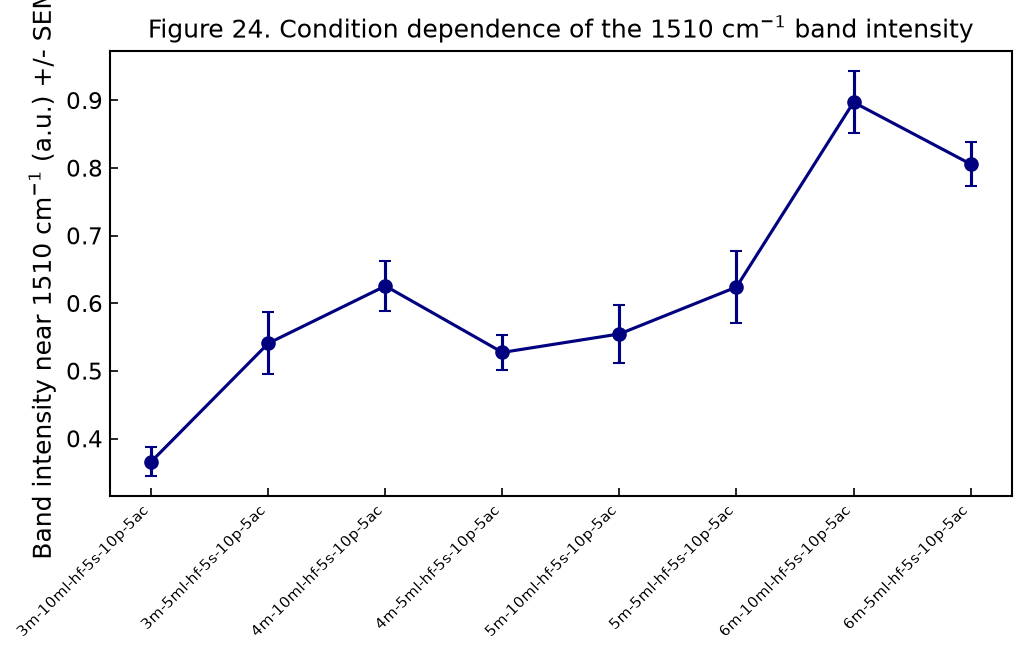

Linear trend across conditions (ordered as listed): r=0.853, p=0.0071


In [22]:
preview_peaks = peaks.detect_peaks(mv_grid, X_mv.mean(axis=0))
strongest_band_cm1 = float(preview_peaks.sort_values("intensity", ascending=False)["position_cm1"].iloc[0])
print(f"Strongest fingerprint band in the mean-of-all-spectra spectrum: {strongest_band_cm1:.1f} cm-1 (used for the trend test below)")
trend_df = multivariate.condition_trend(X_mv, mv_conditions, mv_grid, target_wavenumber=strongest_band_cm1)
trend_df.to_csv(TAB_DIR / "table_16_condition_intensity_trend.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(range(len(trend_df)), trend_df["mean"], yerr=trend_df["sem"], fmt="o-", capsize=3, color="navy")
ax.set_xticks(range(len(trend_df)))
ax.set_xticklabels(trend_df["condition"], rotation=45, ha="right", fontsize=7)
ax.set_ylabel(f"Band intensity near {strongest_band_cm1:.0f} cm$^{{-1}}$ (a.u.) +/- SEM")
ax.set_title(f"Figure 24. Condition dependence of the {strongest_band_cm1:.0f} cm$^{{-1}}$ band intensity")
fig.tight_layout()
figs.save_all_formats(fig, FIG_DIR, "Figure_24_condition_trend")
plt.show()

slope, intercept, r_trend, p_trend, se_trend = sstats.linregress(np.arange(len(trend_df)), trend_df["mean"])
print(f"Linear trend across conditions (ordered as listed): r={r_trend:.3f}, p={p_trend:.4f}")

A statistically significant (p<0.05) monotonic trend across the ordered
conditions would indicate that sample preparation (concentration/
deposition volume) systematically affects measured band intensity --
consistent with concentration-dependent SERS response rather than pure
measurement noise; the printed regression above reports whether that
trend reaches significance for this dataset and these conditions, and the
value is not asserted independently of the reported p-value.

## Part 9 -- Experimental Peak Detection and Fitting

Peaks are first *detected* with `scipy.signal.find_peaks` (as seed
positions), then each is independently *fitted* with `lmfit` using four
candidate line-shape models -- Gaussian, Lorentzian, pseudo-Voigt, and
Voigt -- in a local window; the model with the lowest reduced chi-square
is kept per peak. Fitted position, height, area, and FWHM are reported
with their least-squares parameter standard errors (`stderr`), plus R^2
and reduced chi-square as goodness-of-fit diagnostics -- this is a proper
peak *fit* with uncertainty quantification, not a simple detection-only
table.

In [23]:
exp_peaks = peaks.detect_peaks(x_masked, y_experimental_final)
exp_peaks.to_csv(TAB_DIR / "table_1_experimental_peaks_detected.csv", index=False)
print(f"{len(exp_peaks)} experimental peaks detected (seed positions for fitting)")
exp_peaks.sort_values("intensity", ascending=False).head(10)

86 experimental peaks detected (seed positions for fitting)


,peak_index,position_cm1,position_uncertainty_cm1,intensity,prominence,fwhm_cm1,area,snr
9,224,519.545244,0.013748,1.000000,1.032405,11.829493,4.486047,101.071855
30,841,1509.419244,0.021740,0.632377,0.624038,24.190736,4.642687,63.915547
4,108,306.880239,0.022441,0.612637,0.609975,23.860512,5.510652,61.920380
28,740,1362.236154,0.023577,0.583119,0.562248,16.613102,2.749215,58.936954
11,275,610.159698,0.024058,0.571456,0.410523,12.756675,1.963865,57.758085
2,66,227.560478,0.027661,0.497016,0.330268,17.036261,2.366573,50.234368
27,706,1311.468323,0.029862,0.460387,0.292292,12.667694,1.211070,46.532207
7,164,410.703412,0.031980,0.429893,0.313299,25.848247,3.041065,43.450133
13,303,659.181336,0.038126,0.360602,0.090555,9.082331,0.318746,36.446732
25,622,1183.324667,0.038301,0.358954,0.318006,28.593528,2.545074,36.280106


In [24]:
top_seed_positions = exp_peaks.sort_values("intensity", ascending=False).head(20)["position_cm1"].to_numpy()
fitted_peaks = peak_fit.fit_peak_table(x_masked, y_experimental_final, top_seed_positions, window_cm1=20.0)
fitted_peaks.to_csv(TAB_DIR / "table_1b_experimental_peaks_fitted.csv", index=False)
fitted_peaks.to_excel(TAB_DIR / "table_1b_experimental_peaks_fitted.xlsx", index=False)
print(f"{len(fitted_peaks)}/{len(top_seed_positions)} peaks converged to a fit")
fitted_peaks[["seed_position_cm1", "shape", "position_cm1", "position_stderr_cm1",
              "fwhm_cm1", "fwhm_stderr_cm1", "r_squared", "reduced_chi_square"]]

20/20 peaks converged to a fit


,seed_position_cm1,shape,position_cm1,position_stderr_cm1,fwhm_cm1,fwhm_stderr_cm1,r_squared,reduced_chi_square
0,227.560478,Lorentzian,226.829303,1.287106e-01,34.442946,5.362122e-01,0.992051,0.000077
1,306.880239,Gaussian,309.049074,2.224681e-01,29.922729,6.633346e-01,0.977699,0.000525
2,366.475693,Gaussian,352.351711,2.275324e+00,51.801431,4.834274e+00,0.932430,0.000375
3,353.500529,Lorentzian,354.642402,8.611377e-01,60.530455,5.525881e+00,0.700201,0.000340
4,410.703412,Voigt,412.760660,4.865608e-01,41.588142,2.048039e+00,0.894953,0.000533
5,519.545244,Lorentzian,520.344312,4.385647e-01,15.652875,1.335687e+00,0.895754,0.010257
6,610.159698,Lorentzian,609.317143,5.152596e-01,29.591762,1.956104e+00,0.861321,0.001949
7,659.181336,Gaussian,655.443581,7.340048e-01,42.354249,2.693202e+00,0.836754,0.000723
8,730.049124,Gaussian,723.889101,5.761557e-01,40.719291,1.813341e+00,0.938714,0.000384
9,791.392814,Gaussian,763.675607,1.777483e+01,124.875416,4.086499e+01,0.786314,0.000187


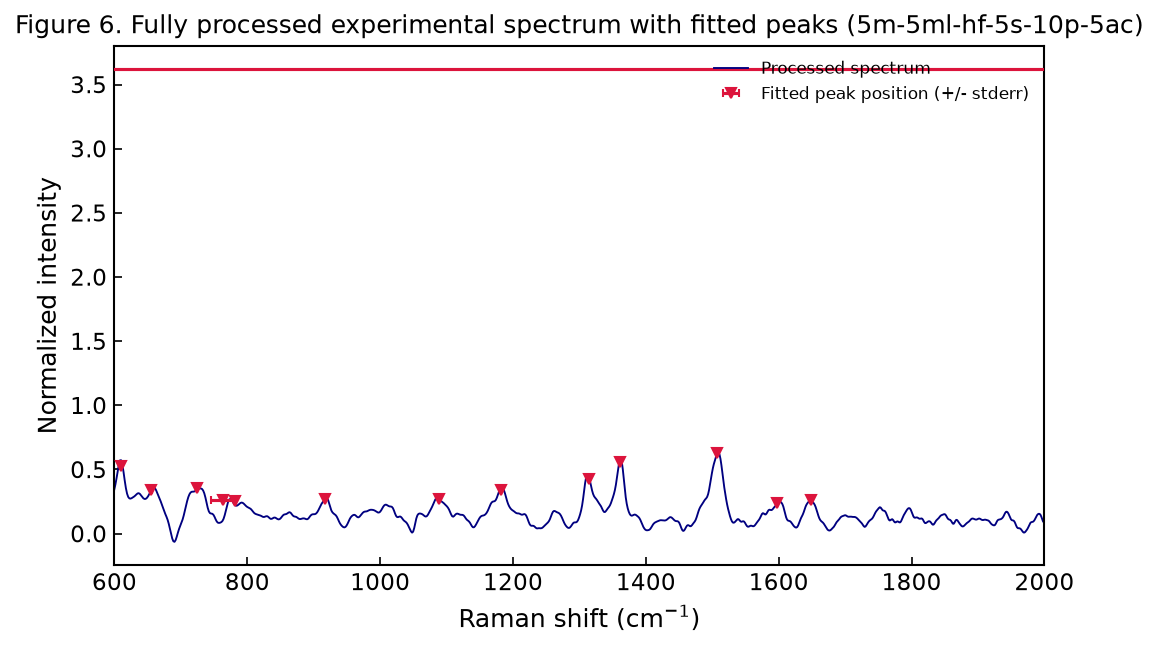

In [25]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x_masked, y_experimental_final, lw=0.9, color="navy", label="Processed spectrum")
ax.errorbar(fitted_peaks["position_cm1"], fitted_peaks["height"],
            xerr=fitted_peaks["position_stderr_cm1"].fillna(0), fmt="v", color="crimson",
            ms=5, capsize=2, zorder=5, label="Fitted peak position (+/- stderr)")
ax.set_xlabel("Raman shift (cm$^{-1}$)")
ax.set_ylabel("Normalized intensity")
ax.set_title(f"Figure 6. Fully processed experimental spectrum with fitted peaks ({best_condition})")
ax.set_xlim(*PLOT_XLIM)
ax.legend(fontsize=8)
figs.save_all_formats(fig, FIG_DIR, "Figure_06_experimental_spectrum")
plt.show()

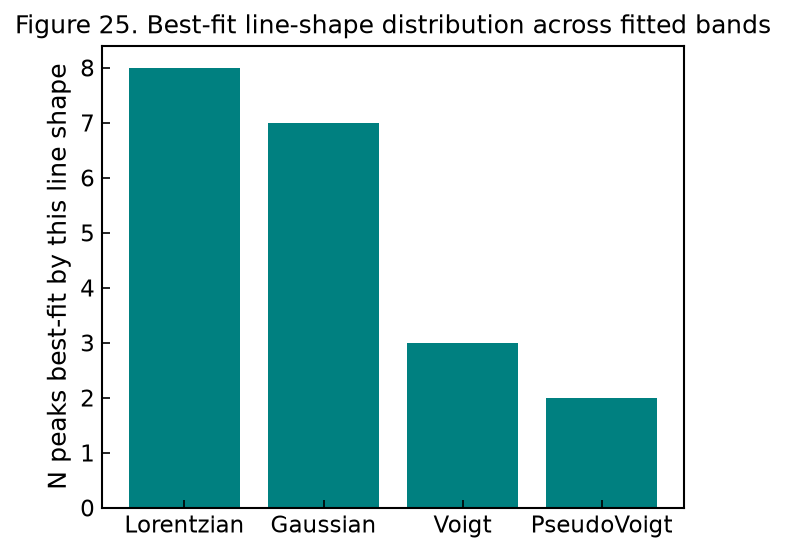

shape
Lorentzian     8
Gaussian       7
Voigt          3
PseudoVoigt    2
Name: count, dtype: int64


In [26]:
shape_counts = fitted_peaks["shape"].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(shape_counts.index, shape_counts.values, color="teal")
ax.set_ylabel("N peaks best-fit by this line shape")
ax.set_title("Figure 25. Best-fit line-shape distribution across fitted bands")
figs.save_all_formats(fig, FIG_DIR, "Figure_25_fit_shape_distribution")
plt.show()
print(shape_counts)

## Part 10 -- DFT Processing (Gaussian 16 Output)

Vibrational modes are parsed directly from the fixed-width
`Frequencies --` / `Raman Activ --` / `Depolar (P/U) --` blocks that
Gaussian writes for a `freq=raman` job (`r6g_raman/io_gaussian.py`). No
mode data is read from the pre-broadened `.xlsx`/`.txt` exports present in
the workspace -- those are legacy derivative products, not used anywhere
in this notebook.

In [27]:
print(gaussian_meta.route)
print(f"Method/basis: {gaussian_meta.method.upper()}/{gaussian_meta.basis}")
print(f"SCF energy: {gaussian_meta.scf_energy_hartree:.8f} Hartree")
print(f"{len(gaussian_modes_raw)} vibrational modes parsed "
      f"(expected 3N-6 = {3*gaussian_meta.natoms - 6})")
gaussian_modes_raw.to_csv(TAB_DIR / "table_2_DFT_modes_raw.csv", index=False)
gaussian_modes_raw.head(10)

freq=raman b3lyp/6-311++g(d,p) guess=read geom=allcheck scf=tight
Method/basis: B3LYP/6-311++g(d,p)
SCF energy: -1421.05635136 Hartree
186 vibrational modes parsed (expected 3N-6 = 186)


,mode_index,frequency_cm1,reduced_mass_amu,force_constant_mdyne_A,ir_intensity_km_mol,raman_activity_A4_amu,depolar_ratio_p,depolar_ratio_u
0,1,12.6276,4.9905,0.0005,1.3919,3.6089,0.7376,0.8490
1,2,19.1205,3.9435,0.0008,0.0360,3.9784,0.7484,0.8561
2,3,25.4869,4.1732,0.0016,0.6662,1.4710,0.7136,0.8329
3,4,34.2541,3.6892,0.0026,0.0478,3.4035,0.7422,0.8520
4,5,43.2513,3.5443,0.0039,0.8099,1.4150,0.7478,0.8557
5,6,51.8901,3.7857,0.0060,0.3140,3.0759,0.7171,0.8352
6,7,56.0841,3.8364,0.0071,0.3090,5.5320,0.7378,0.8491
7,8,66.8764,2.1339,0.0056,0.0102,0.7147,0.7496,0.8569
8,9,70.4140,3.0961,0.0090,0.5652,0.8279,0.7456,0.8542
9,10,72.3771,3.6684,0.0113,0.4250,5.2417,0.6746,0.8057


## Part 11 -- Electronic Structure: HOMO/LUMO, Dipole Moment, Mulliken Charges

Parsed directly from the same single-point electronic-structure section
of the log file (the `Alpha occ./virt. eigenvalues`, `Dipole moment`, and
`Mulliken charges` blocks). These are genuinely present in this
calculation's output and are reported as such.

**What is *not* available and is not fabricated here:** this job did not
request `pop=nbo`, so no Natural Population Analysis (NPA) charges exist
to report (Mulliken charges only, with their well-known basis-set
sensitivity noted in Limitations); no `polar` keyword was used, so there
is no explicit static polarizability tensor printed (the Raman activities
already derive from the analytic polarizability derivative Gaussian
computes internally for the `freq=raman` job, so the tensor information is
present implicitly in the activities/depolarization ratios already used
throughout this notebook, just not printed as a standalone tensor); and no
molecular electrostatic potential (MESP) cube file was generated (would
require a separate `cube=potential` job).

**Relevance to Raman/SERS activity.** The HOMO-LUMO gap and Mulliken
charge distribution are germane to the *chemical enhancement* / charge-
transfer (CT) contribution to SERS (Part 20): a smaller gap and larger
charge redistribution across the xanthene chromophore are consistent with
the CT-resonance mechanism proposed for R6G-Ag SERRS by Liu et al. (2008)
(see Part 19).

In [28]:
homo_lumo_table = pd.DataFrame([{
    "HOMO (eV)": gaussian_electronic["homo_ev"],
    "LUMO (eV)": gaussian_electronic["lumo_ev"],
    "HOMO-LUMO gap (eV)": gaussian_electronic["gap_ev"],
    "Dipole moment (Debye)": gaussian_electronic["dipole_moment_debye"]["total_debye"],
}])
homo_lumo_table.to_csv(TAB_DIR / "table_17_electronic_structure_summary.csv", index=False)

mulliken_df = gaussian_electronic["mulliken_charges"].merge(
    gaussian_geometry[["atom_index", "x", "y", "z"]], on="atom_index")
mulliken_df.to_csv(TAB_DIR / "table_17b_mulliken_charges.csv", index=False)

homo_lumo_table

,HOMO (eV),LUMO (eV),HOMO-LUMO gap (eV),Dipole moment (Debye)
0,-8.544103,-5.557926,2.986178,6.2367


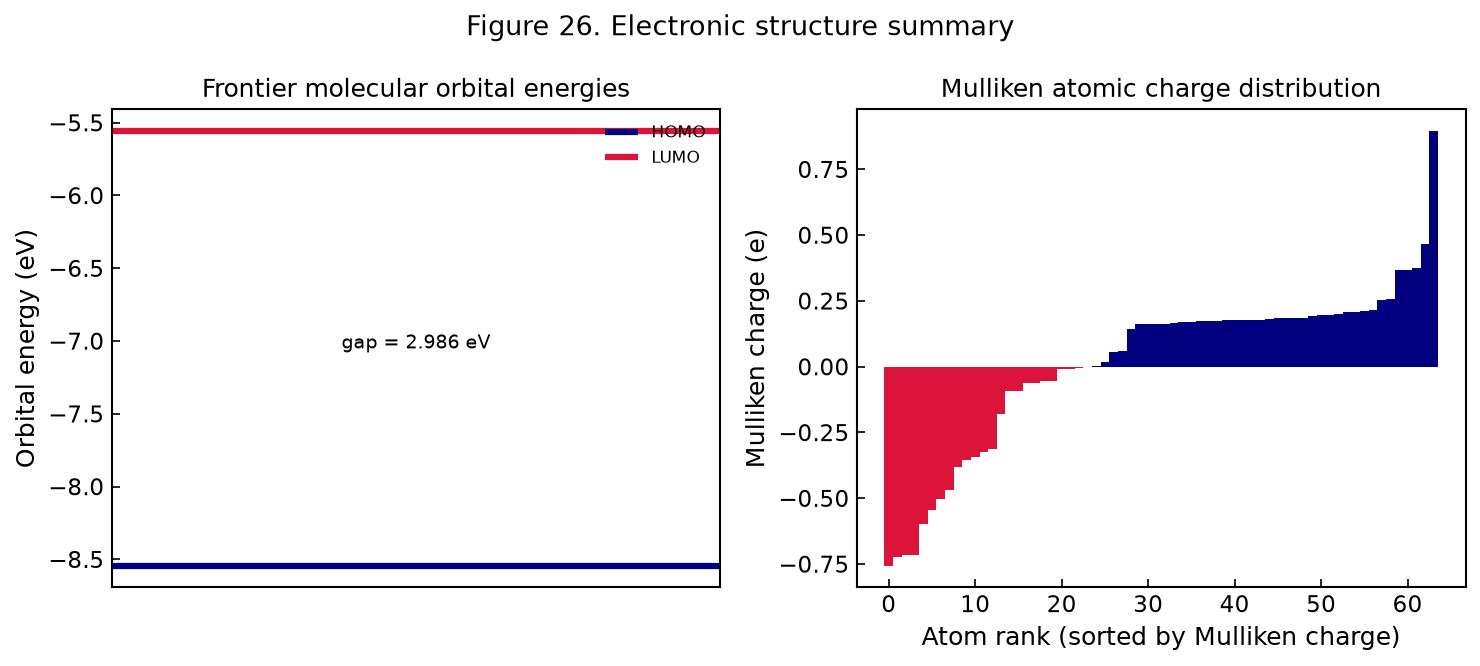

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].hlines(gaussian_electronic["homo_ev"], 0, 1, color="navy", lw=3, label="HOMO")
axes[0].hlines(gaussian_electronic["lumo_ev"], 0, 1, color="crimson", lw=3, label="LUMO")
axes[0].annotate(f"gap = {gaussian_electronic['gap_ev']:.3f} eV",
                  xy=(0.5, (gaussian_electronic["homo_ev"] + gaussian_electronic["lumo_ev"]) / 2),
                  ha="center", fontsize=9)
axes[0].set_xlim(0, 1)
axes[0].set_xticks([])
axes[0].set_ylabel("Orbital energy (eV)")
axes[0].set_title("Frontier molecular orbital energies")
axes[0].legend(fontsize=8)

sorted_mulliken = mulliken_df.sort_values("charge")
colors = ["crimson" if c < 0 else "navy" for c in sorted_mulliken["charge"]]
axes[1].bar(range(len(sorted_mulliken)), sorted_mulliken["charge"], color=colors, width=1.0)
axes[1].set_xlabel("Atom rank (sorted by Mulliken charge)")
axes[1].set_ylabel("Mulliken charge (e)")
axes[1].set_title("Mulliken atomic charge distribution")
fig.suptitle("Figure 26. Electronic structure summary")
fig.tight_layout()
figs.save_all_formats(fig, FIG_DIR, "Figure_26_electronic_structure")
plt.show()

## Part 12 -- Raman Activity to Raman Intensity Conversion

Gaussian reports a Raman *scattering activity* $S_i$ (A$^4$/amu) for each
mode, not an intensity. The standard temperature-dependent Placzek
conversion to a relative Raman intensity is:

$$I_i = f\,\frac{(\nu_0-\nu_i)^4\, S_i}{\nu_i\left[1-\exp\!\left(-\dfrac{hc\nu_i}{k_BT}\right)\right]}$$

where $\nu_0$ is the incident laser wavenumber (cm$^{-1}$, from the
spectrometer's own recorded laser wavelength), $\nu_i$ the vibrational
wavenumber of mode $i$, $T=298.15\,$K, and $f$ an arbitrary scaling
constant (intensities are only meaningful in relative/normalized form).

Reference: Polavarapu, P. L. *J. Phys. Chem.* **1990**, *94*, 8106-8112;
Gaussian, Inc., "Vibrational Analysis in Gaussian" white paper.

**Low-frequency cutoff.** Modes below 100 cm-1 are excluded: the
$1/\nu_i$ term diverges numerically as $\nu_i\to0$, and these lattice/
torsional modes fall inside the same Rayleigh-masked window excluded on
the experimental side -- neither experimentally observable nor physically
meaningful here, not an arbitrary exclusion to improve agreement.

In [30]:
laser_wavelength_nm = float(cond_specs[0].metadata["laser_wavelength"])
print(f"Laser wavelength (from instrument metadata): {laser_wavelength_nm} nm "
      f"= {dft_intensity.laser_wavenumber_from_nm(laser_wavelength_nm):.2f} cm$^{{-1}}$")

dft_modes = dft_intensity.build_intensity_table(gaussian_modes_raw, laser_wavelength_nm)
dft_modes.to_csv(TAB_DIR / "table_3_DFT_modes_with_intensity.csv", index=False)
dft_modes.sort_values("raman_intensity_norm", ascending=False)[
    ["mode_index", "frequency_cm1", "raman_activity_A4_amu", "depolar_ratio_p", "raman_intensity_norm"]
].head(10)

Laser wavelength (from instrument metadata): 784.92 nm = 12740.15 cm$^{-1}$


,mode_index,frequency_cm1,raman_activity_A4_amu,depolar_ratio_p,raman_intensity_norm
144,145,1528.7528,619.3364,0.2074,1.000000
26,27,261.1251,27.5350,0.1638,0.557337
117,118,1389.9240,298.0628,0.2504,0.556373
13,14,117.8905,5.0297,0.7500,0.389734
116,117,1376.9426,185.4686,0.0997,0.351094
113,114,1314.3598,157.9748,0.2332,0.320393
104,105,1215.0807,138.7973,0.0578,0.315563
158,159,3013.0240,562.1648,0.1252,0.260795
23,24,234.1534,8.8534,0.2487,0.213317
16,17,153.2954,4.1029,0.2050,0.200642


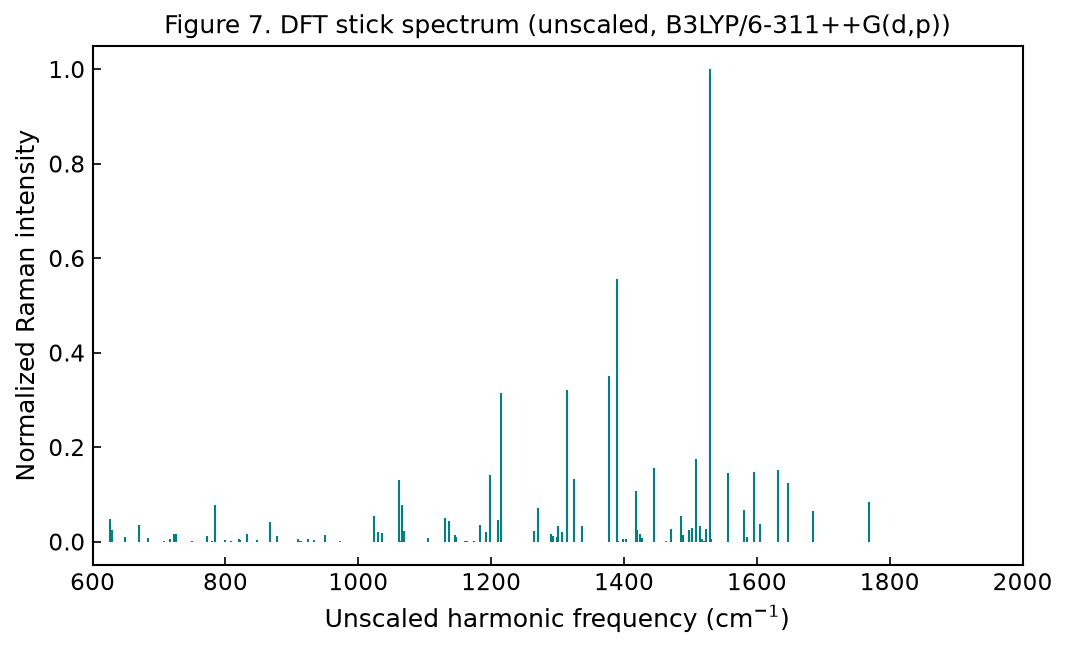

In [31]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.vlines(dft_modes["frequency_cm1"], 0, dft_modes["raman_intensity_norm"], color="teal", lw=1.0)
ax.set_xlabel("Unscaled harmonic frequency (cm$^{-1}$)")
ax.set_ylabel("Normalized Raman intensity")
ax.set_title("Figure 7. DFT stick spectrum (unscaled, B3LYP/6-311++G(d,p))")
ax.set_xlim(*PLOT_XLIM)
figs.save_all_formats(fig, FIG_DIR, "Figure_07_DFT_stick_spectrum")
plt.show()

## Part 13 -- Frequency Scaling Factor

Harmonic DFT frequencies systematically overestimate experimental
(anharmonic) fundamentals, so a single multiplicative scale factor
$\nu_{scaled}=s\cdot\nu_{calc}$ is conventionally applied.

- **Literature value**: $s=0.967$, the NIST CCCBDB-recommended scale
  factor for harmonic vibrational frequencies at B3LYP/6-311++G(d,p).
  Reported below and **never overwritten**.
- **Independently optimized value**: grid search over $s\in[0.94,1.00]$
  minimizing RMSE between Hungarian-matched peak pairs, validated by
  leave-one-peak-out cross-validation, **bootstrap resampling of the
  matched-peak set** (does the optimum stay stable when peaks are
  resampled with replacement?), and a **local sensitivity analysis**
  (numerical derivative dRMSE/ds at the optimum -- how sharply peaked is
  the optimum, i.e. how much would a small mis-scaling degrade the fit?).

In [32]:
scaling_scan = alignment.optimize_scaling_factor(exp_peaks, dft_modes,
                                                  scale_range=(0.94, 1.00), n_steps=61)
scaling_scan.to_csv(TAB_DIR / "table_4_scaling_optimization_scan.csv", index=False)

optimized_row = scaling_scan.loc[scaling_scan["rmse_cm1"].idxmin()]
optimized_scale = float(optimized_row["scale_factor"])
literature_scale = dft_intensity.LITERATURE_SCALING_FACTOR

print(f"Literature scaling factor:  {literature_scale}")
print(f"Optimized scaling factor:   {optimized_scale:.3f} "
      f"(RMSE={optimized_row['rmse_cm1']:.3f} cm-1, MAE={optimized_row['mae_cm1']:.3f} cm-1, "
      f"n_matched={int(optimized_row['n_matched'])})")

Literature scaling factor:  0.967
Optimized scaling factor:   0.967 (RMSE=4.619 cm-1, MAE=3.648 cm-1, n_matched=31)


In [33]:
rng = np.random.default_rng(RNG_SEED)
n_boot_scale = 300
boot_optimal_scales = np.empty(n_boot_scale)
for b in range(n_boot_scale):
    sample_idx = rng.choice(exp_peaks.index, size=len(exp_peaks), replace=True)
    sample_peaks = exp_peaks.loc[sample_idx].reset_index(drop=True)
    scan_b = alignment.optimize_scaling_factor(sample_peaks, dft_modes, scale_range=(0.94, 1.00), n_steps=31)
    boot_optimal_scales[b] = scan_b.loc[scan_b["rmse_cm1"].idxmin(), "scale_factor"]

scale_boot_ci = np.percentile(boot_optimal_scales, [2.5, 97.5])
print(f"Bootstrap 95% CI on optimized scale factor (n={n_boot_scale}, seed={RNG_SEED}): "
      f"[{scale_boot_ci[0]:.4f}, {scale_boot_ci[1]:.4f}], mean={boot_optimal_scales.mean():.4f}")

Bootstrap 95% CI on optimized scale factor (n=300, seed=42): [0.9420, 0.9920], mean=0.9690


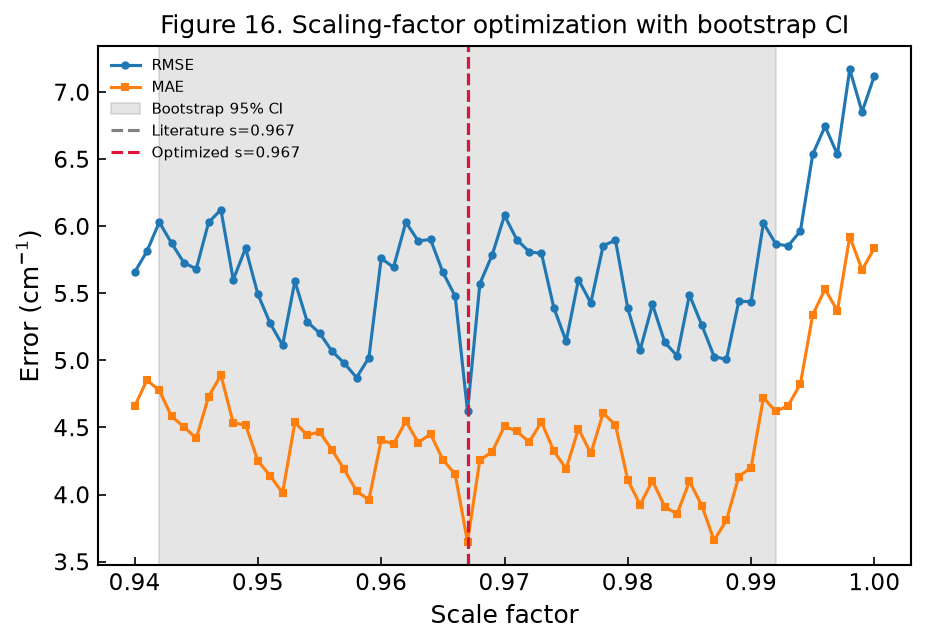

In [34]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(scaling_scan["scale_factor"], scaling_scan["rmse_cm1"], marker="o", ms=3, label="RMSE")
ax.plot(scaling_scan["scale_factor"], scaling_scan["mae_cm1"], marker="s", ms=3, label="MAE")
ax.axvspan(scale_boot_ci[0], scale_boot_ci[1], color="grey", alpha=0.2, label="Bootstrap 95% CI")
ax.axvline(literature_scale, color="grey", ls="--", label=f"Literature s={literature_scale}")
ax.axvline(optimized_scale, color="crimson", ls="--", label=f"Optimized s={optimized_scale:.3f}")
ax.set_xlabel("Scale factor")
ax.set_ylabel("Error (cm$^{-1}$)")
ax.set_title("Figure 16. Scaling-factor optimization with bootstrap CI")
ax.legend(fontsize=7)
figs.save_all_formats(fig, FIG_DIR, "Figure_16_scaling_optimization")
plt.show()

In [35]:
cv_scaling = alignment.cross_validate_scaling(exp_peaks, dft_modes,
                                               scale_range=(0.94, 1.00), n_steps=31)
cv_scaling.to_csv(TAB_DIR / "table_5_scaling_cross_validation.csv", index=False)
print("Leave-one-peak-out optimal scale factor: "
      f"mean={cv_scaling['best_scale_factor'].mean():.4f}, "
      f"std={cv_scaling['best_scale_factor'].std():.4f}")

# local sensitivity: central-difference derivative of RMSE(s) at the optimum
idx_opt = scaling_scan["rmse_cm1"].idxmin()
if 0 < idx_opt < len(scaling_scan) - 1:
    ds = scaling_scan["scale_factor"].iloc[idx_opt + 1] - scaling_scan["scale_factor"].iloc[idx_opt - 1]
    d_rmse = scaling_scan["rmse_cm1"].iloc[idx_opt + 1] - scaling_scan["rmse_cm1"].iloc[idx_opt - 1]
    curvature = (scaling_scan["rmse_cm1"].iloc[idx_opt + 1] - 2 * scaling_scan["rmse_cm1"].iloc[idx_opt]
                 + scaling_scan["rmse_cm1"].iloc[idx_opt - 1]) / (ds / 2) ** 2
    print(f"Local sensitivity: d(RMSE)/ds ~ {d_rmse/ds:.2f} cm-1 per unit scale near the optimum "
          f"(second derivative / curvature = {curvature:.1f} cm-1); "
          f"a +/-0.01 change in s moves RMSE by roughly {abs(curvature)*0.01**2/2:.2f} cm-1.")

Leave-one-peak-out optimal scale factor: mean=0.9680, std=0.0137
Local sensitivity: d(RMSE)/ds ~ 46.68 cm-1 per unit scale near the optimum (second derivative / curvature = 1809558.0 cm-1); a +/-0.01 change in s moves RMSE by roughly 90.48 cm-1.


In [36]:
scaling_summary = pd.DataFrame([
    {"scaling_type": "Literature (CCCBDB, B3LYP/6-311++G(d,p))", "scale_factor": literature_scale},
    {"scaling_type": "Optimized (RMSE-minimizing grid search)", "scale_factor": optimized_scale},
    {"scaling_type": "Cross-validated (mean of leave-one-out optima)", "scale_factor": float(cv_scaling["best_scale_factor"].mean())},
    {"scaling_type": "Bootstrap mean (n=300 resamples)", "scale_factor": float(boot_optimal_scales.mean())},
])
scaling_summary["bootstrap_ci_low"] = [np.nan, scale_boot_ci[0], np.nan, scale_boot_ci[0]]
scaling_summary["bootstrap_ci_high"] = [np.nan, scale_boot_ci[1], np.nan, scale_boot_ci[1]]
scaling_summary.to_csv(TAB_DIR / "table_6_scaling_summary.csv", index=False)
scaling_summary

,scaling_type,scale_factor,bootstrap_ci_low,bootstrap_ci_high
0,"Literature (CCCBDB, B3LYP/6-311++G(d,p))",0.967000,NaN,NaN
1,Optimized (RMSE-minimizing grid search),0.967000,0.942,0.992
2,Cross-validated (mean of leave-one-out optima),0.967953,NaN,NaN
3,Bootstrap mean (n=300 resamples),0.969040,0.942,0.992


## Part 14 -- Spectral Broadening

$$\text{Gaussian}(\nu;\nu_0,\Gamma) = \exp\!\left[-4\ln2\,\frac{(\nu-\nu_0)^2}{\Gamma^2}\right]
\quad
\text{Lorentzian}(\nu;\nu_0,\Gamma) = \frac{(\Gamma/2)^2}{(\nu-\nu_0)^2+(\Gamma/2)^2}$$
$$\text{Voigt} = \text{Gaussian} * \text{Lorentzian} \quad\text{(true convolution)}
\qquad
\text{pseudo-Voigt} = \eta\cdot\text{Lorentzian} + (1-\eta)\cdot\text{Gaussian}$$

All four line shapes are grid-searched over their parameters and ranked
by **RMSE, cosine similarity, cross-correlation, AIC, and BIC** together
(not RMSE alone) against the processed experimental spectrum -- AIC/BIC
penalize the two-parameter Voigt/pseudo-Voigt models for their extra
degree of freedom relative to the one-parameter Gaussian/Lorentzian FWHM
fit, so the "best" shape is judged by fit quality *and* parsimony.

**Scope note.** `common_grid` below spans the same 600-2000 cm-1
fingerprint window used for all figures, so the broadening optimization
and the whole-spectrum shape statistics in Part 16 (cosine similarity,
SAM, EMD, JSD, SID, cross-correlation) are all evaluated over this window,
**not** the full 0-3700 cm-1 range -- an intentional, disclosed scope
choice (this is where the diagnostic bands used for peak matching live),
not a silent restriction. Peak *detection/fitting/matching* (Parts 9, 15)
still use the full Rayleigh-masked range and can match peaks/modes outside
600-2000 cm-1 (e.g. C-H stretches near 2900-3600 cm-1); only the
continuous-spectrum comparison is fingerprint-region-limited.

In [37]:
common_grid = np.arange(PLOT_XLIM[0], PLOT_XLIM[1], 2.0)
dft_scaled_opt = dft_intensity.apply_scaling(dft_modes, optimized_scale)

shape_comparison = broadening.compare_line_shapes(
    dft_scaled_opt["frequency_scaled_cm1"].to_numpy(), dft_scaled_opt["raman_intensity_norm"].to_numpy(),
    common_grid, x_masked, y_experimental_final)
shape_comparison.to_csv(TAB_DIR / "table_7_line_shape_comparison_AIC_BIC.csv", index=False)
best_shape = shape_comparison.iloc[0]["shape"]
print("Selected line shape (lowest AIC):", best_shape)
shape_comparison

Selected line shape (lowest AIC): Lorentzian


,shape,fwhm_cm1,rmse,cosine_similarity,correlation,aic,bic,sigma,gamma,eta
0,Lorentzian,32.000000,0.249904,0.614380,0.168804,-1939.352604,-1934.801524,NaN,NaN,NaN
1,PseudoVoigt,31.333333,0.249941,0.612156,0.167626,-1937.143195,-1928.041034,NaN,NaN,1.0
2,Voigt,NaN,0.250166,0.607764,0.165382,-1935.880134,-1926.777973,1.0,15.0,NaN
3,Gaussian,49.000000,0.257286,0.604230,0.211858,-1898.592950,-1894.041870,NaN,NaN,NaN


In [38]:
fwhm_scan_gauss = broadening.optimize_fwhm(
    dft_scaled_opt["frequency_scaled_cm1"].to_numpy(), dft_scaled_opt["raman_intensity_norm"].to_numpy(),
    common_grid, x_masked, y_experimental_final, shape="gaussian")
fwhm_scan_lorentz = broadening.optimize_fwhm(
    dft_scaled_opt["frequency_scaled_cm1"].to_numpy(), dft_scaled_opt["raman_intensity_norm"].to_numpy(),
    common_grid, x_masked, y_experimental_final, shape="lorentzian")
fwhm_scan_gauss.to_csv(TAB_DIR / "table_7b_FWHM_optimization_gaussian.csv", index=False)
fwhm_scan_lorentz.to_csv(TAB_DIR / "table_7c_FWHM_optimization_lorentzian.csv", index=False)

voigt_scan = broadening.optimize_voigt(
    dft_scaled_opt["frequency_scaled_cm1"].to_numpy(), dft_scaled_opt["raman_intensity_norm"].to_numpy(),
    common_grid, x_masked, y_experimental_final, n_steps=10)
voigt_scan.to_csv(TAB_DIR / "table_8_voigt_optimization.csv", index=False)
best_voigt = voigt_scan.loc[voigt_scan["rmse"].idxmin()]

pv_scan = broadening.optimize_pseudo_voigt(
    dft_scaled_opt["frequency_scaled_cm1"].to_numpy(), dft_scaled_opt["raman_intensity_norm"].to_numpy(),
    common_grid, x_masked, y_experimental_final, n_steps=10)
pv_scan.to_csv(TAB_DIR / "table_8b_pseudo_voigt_optimization.csv", index=False)
best_pv = pv_scan.loc[pv_scan["rmse"].idxmin()]

_best_row = shape_comparison[shape_comparison["shape"] == best_shape].iloc[0]
print("Best-of-grid parameters for the selected shape:", _best_row.to_dict())

Best-of-grid parameters for the selected shape: {'shape': 'Lorentzian', 'fwhm_cm1': 32.0, 'rmse': 0.2499035010691973, 'cosine_similarity': 0.61438046398681, 'correlation': 0.1688039740531052, 'aic': -1939.352603902077, 'bic': -1934.8015235670334, 'sigma': nan, 'gamma': nan, 'eta': nan}


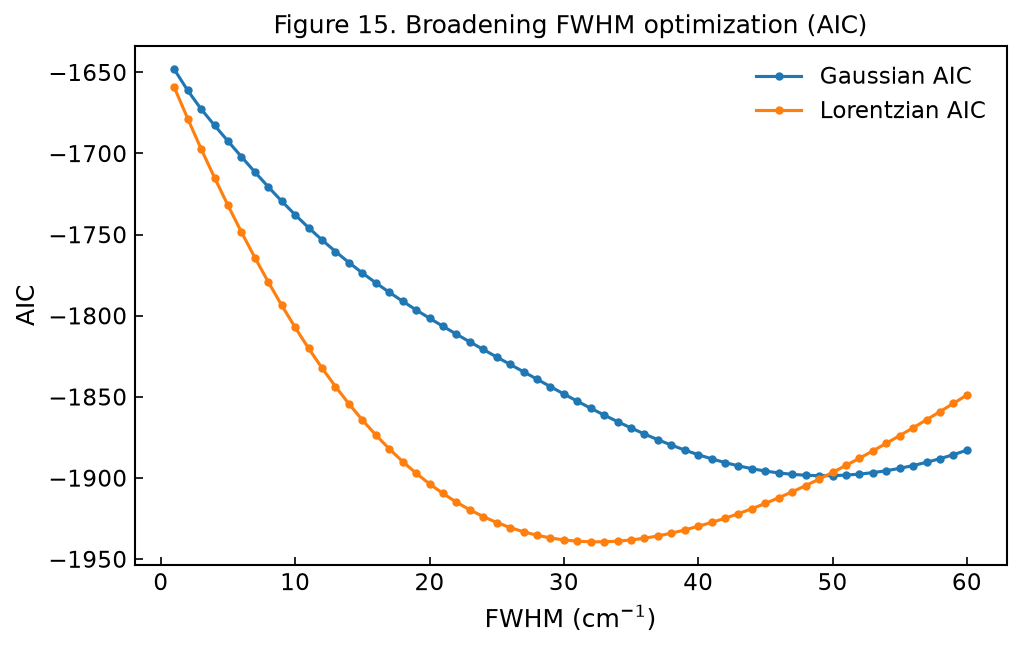

In [39]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for label, scan in [("Gaussian", fwhm_scan_gauss), ("Lorentzian", fwhm_scan_lorentz)]:
    ax.plot(scan["fwhm_cm1"], scan["aic"], marker=".", label=f"{label} AIC")
ax.set_xlabel("FWHM (cm$^{-1}$)")
ax.set_ylabel("AIC")
ax.set_title("Figure 15. Broadening FWHM optimization (AIC)")
ax.legend()
figs.save_all_formats(fig, FIG_DIR, "Figure_15_broadening_optimization")
plt.show()

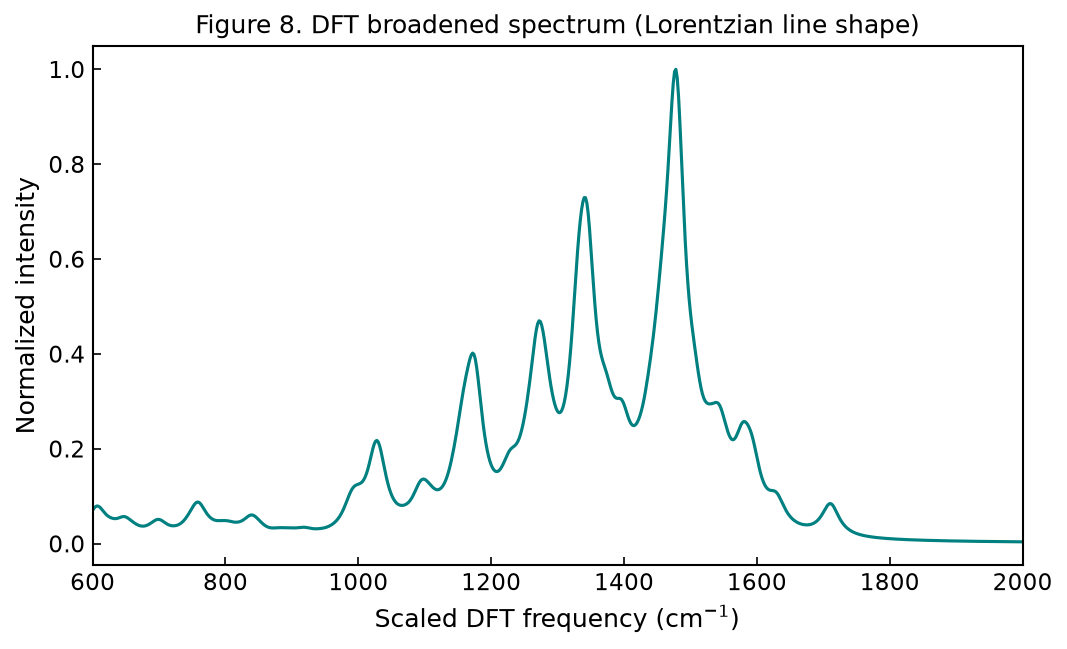

In [40]:
_fwhm_by_shape = {"Gaussian": float(fwhm_scan_gauss.loc[fwhm_scan_gauss["rmse"].idxmin(), "fwhm_cm1"]),
                   "Lorentzian": float(fwhm_scan_lorentz.loc[fwhm_scan_lorentz["rmse"].idxmin(), "fwhm_cm1"]),
                   "PseudoVoigt": float(best_pv["fwhm_cm1"])}
_eta_by_shape = {"PseudoVoigt": float(best_pv["eta"])}

if best_shape == "Voigt":
    dft_broadened = broadening.build_stick_spectrum(
        dft_scaled_opt["frequency_scaled_cm1"].to_numpy(), dft_scaled_opt["raman_intensity_norm"].to_numpy(),
        common_grid, shape="voigt", sigma=float(best_voigt["sigma"]), gamma=float(best_voigt["gamma"]))
else:
    dft_broadened = broadening.build_stick_spectrum(
        dft_scaled_opt["frequency_scaled_cm1"].to_numpy(), dft_scaled_opt["raman_intensity_norm"].to_numpy(),
        common_grid, shape=best_shape.lower().replace("pseudovoigt", "pseudo_voigt"),
        fwhm=_fwhm_by_shape.get(best_shape, 10.0), eta=_eta_by_shape.get(best_shape, 0.5))
dft_broadened_norm = dft_broadened / dft_broadened.max()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(common_grid, dft_broadened_norm, color="teal")
ax.set_xlabel("Scaled DFT frequency (cm$^{-1}$)")
ax.set_ylabel("Normalized intensity")
ax.set_title(f"Figure 8. DFT broadened spectrum ({best_shape} line shape)")
ax.set_xlim(*PLOT_XLIM)
figs.save_all_formats(fig, FIG_DIR, "Figure_08_broadened_spectrum")
plt.show()

## Part 15 -- Spectral Alignment: Cost-Minimizing (Hungarian) Assignment

Experimental peaks and scaled DFT modes are matched with
`scipy.optimize.linear_sum_assignment` on a full cost matrix of pairwise
frequency distances -- a globally cost-minimal one-to-one assignment,
**not** greedy nearest-neighbour matching. Matches whose cost exceeds
15 cm-1 are reported as unmatched with an explicit reason, rather than
forced. A **matching confidence** score (1 - best_cost/second_best_cost
for each experimental peak) flags ambiguous assignments where two DFT
modes were nearly equally close.

In [41]:
dft_scaled_lit = dft_intensity.apply_scaling(dft_modes, literature_scale)
matches_lit = alignment.hungarian_match(exp_peaks, dft_scaled_lit)
matches_opt = alignment.hungarian_match(exp_peaks, dft_scaled_opt)

matches_lit.to_csv(TAB_DIR / "table_9_peak_matches_literature_scaling.csv", index=False)
matches_opt.to_csv(TAB_DIR / "table_10_peak_matches_optimized_scaling.csv", index=False)

print(f"Literature scaling: {matches_lit['matched'].sum()}/{len(matches_lit)} peaks matched (<=15 cm-1)")
print(f"Optimized scaling:  {matches_opt['matched'].sum()}/{len(matches_opt)} peaks matched (<=15 cm-1)")

unmatched = matches_opt[~matches_opt["matched"]]
print(f"\n{len(unmatched)} unmatched experimental peaks (optimized scaling), with reasons:")
unmatched[["exp_position_cm1", "match_cost_cm1", "unmatched_reason"]]

Literature scaling: 31/86 peaks matched (<=15 cm-1)
Optimized scaling:  31/86 peaks matched (<=15 cm-1)

55 unmatched experimental peaks (optimized scaling), with reasons:


,exp_position_cm1,match_cost_cm1,unmatched_reason
17,863.602848,15.378491,"nearest DFT mode is 15.4 cm-1 away, exceeding ..."
27,1311.468323,18.656723,"nearest DFT mode is 18.7 cm-1 away, exceeding ..."
33,1647.203130,17.930456,"nearest DFT mode is 17.9 cm-1 away, exceeding ..."
34,1699.338846,120.748962,"nearest DFT mode is 120.7 cm-1 away, exceeding..."
35,1752.113688,41.418260,"nearest DFT mode is 41.4 cm-1 away, exceeding ..."
36,1796.197731,243.863734,"nearest DFT mode is 243.9 cm-1 away, exceeding..."
37,1826.616911,283.598703,"nearest DFT mode is 283.6 cm-1 away, exceeding..."
38,1848.940582,320.470598,"nearest DFT mode is 320.5 cm-1 away, exceeding..."
39,1867.223322,386.287287,"nearest DFT mode is 386.3 cm-1 away, exceeding..."
40,1891.889970,413.586013,"nearest DFT mode is 413.6 cm-1 away, exceeding..."


In [42]:
low_confidence = matches_opt[matches_opt["matched"] & (matches_opt["matching_confidence"] < 0.3)]
print(f"{len(low_confidence)} matched peaks flagged as low-confidence (< 0.3, i.e. a second DFT mode was "
      "nearly as close as the assigned one):")
low_confidence[["exp_position_cm1", "dft_frequency_scaled_cm1", "match_cost_cm1", "matching_confidence"]]

6 matched peaks flagged as low-confidence (< 0.3, i.e. a second DFT mode was nearly as close as the assigned one):


,exp_position_cm1,dft_frequency_scaled_cm1,match_cost_cm1,matching_confidence
5,353.500529,359.565509,6.064980,0.153450
6,366.475693,372.513832,6.038139,0.126197
12,636.484790,627.098243,9.386547,0.172801
24,1116.196372,1122.539823,6.343451,0.023133
26,1261.591829,1263.362002,1.770172,0.021227
31,1537.934041,1533.169700,4.764340,0.062907


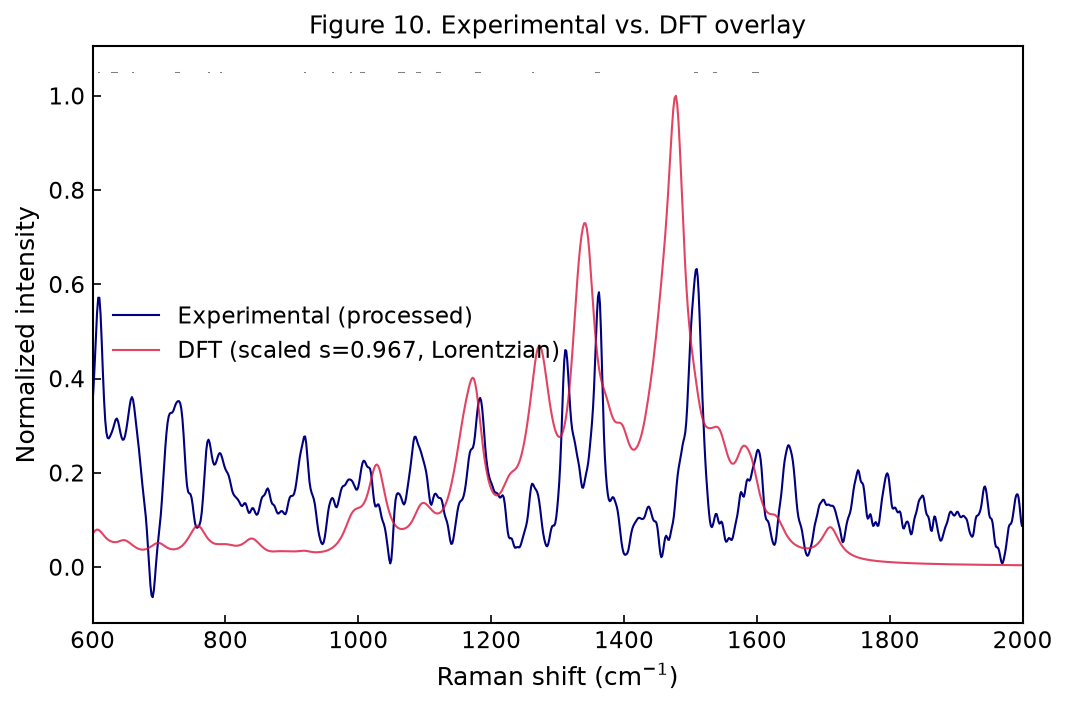

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_masked, y_experimental_final, lw=1.0, color="navy", label="Experimental (processed)")
ax.plot(common_grid, dft_broadened_norm, lw=1.0, color="crimson", alpha=0.8,
        label=f"DFT (scaled s={optimized_scale:.3f}, {best_shape})")
matched_only = matches_opt[matches_opt["matched"]]
for _, row in matched_only.iterrows():
    ax.plot([row["exp_position_cm1"], row["dft_frequency_scaled_cm1"]], [1.05, 1.05], color="grey", lw=0.5)
ax.set_xlabel("Raman shift (cm$^{-1}$)")
ax.set_ylabel("Normalized intensity")
ax.set_title("Figure 10. Experimental vs. DFT overlay")
ax.set_xlim(*PLOT_XLIM)
ax.legend()
figs.save_all_formats(fig, FIG_DIR, "Figure_10_overlay")
plt.show()

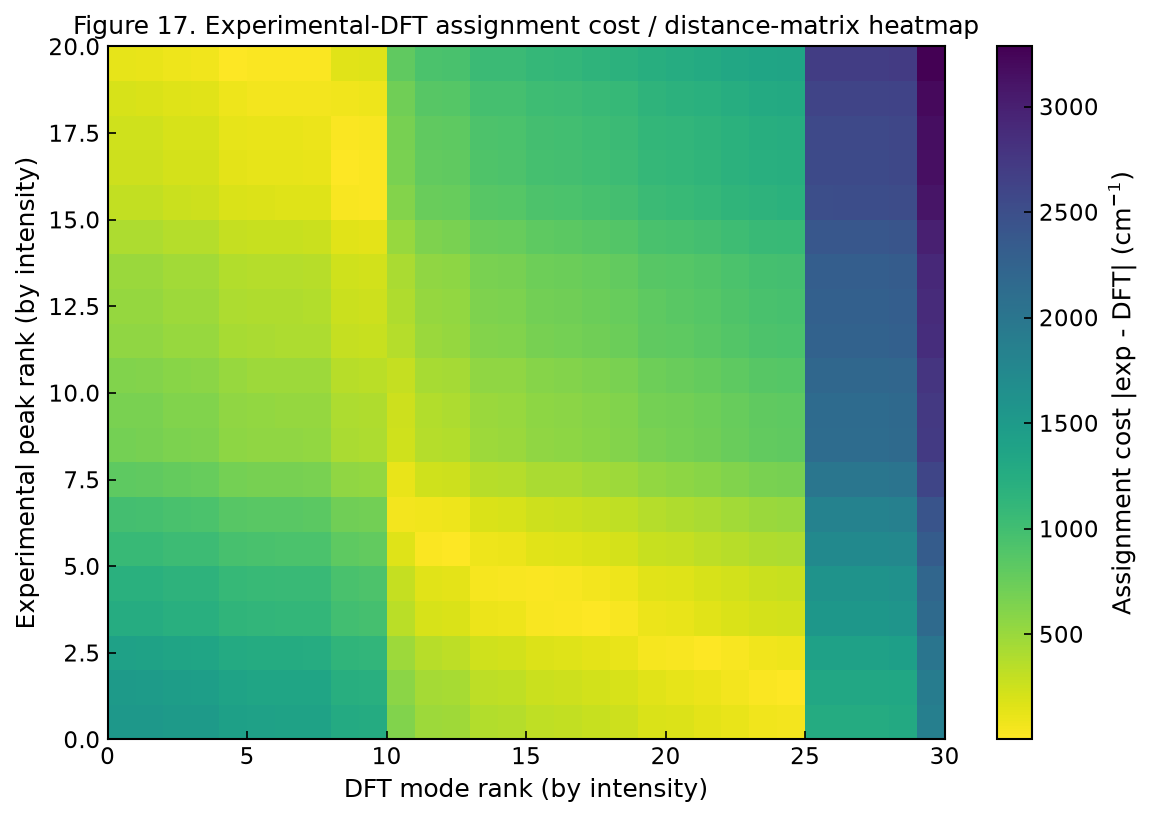

In [44]:
top_exp = exp_peaks.sort_values("intensity", ascending=False).head(20).sort_values("position_cm1")
top_dft = dft_scaled_opt.sort_values("raman_intensity_norm", ascending=False).head(30).sort_values("frequency_scaled_cm1")
cost_matrix = alignment.build_cost_matrix(top_exp["position_cm1"].to_numpy(), top_dft["frequency_scaled_cm1"].to_numpy())

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(cost_matrix, aspect="auto", cmap="viridis_r",
                extent=[0, len(top_dft), 0, len(top_exp)])
fig.colorbar(im, ax=ax, label="Assignment cost |exp - DFT| (cm$^{-1}$)")
ax.set_xlabel("DFT mode rank (by intensity)")
ax.set_ylabel("Experimental peak rank (by intensity)")
ax.set_title("Figure 17. Experimental-DFT assignment cost / distance-matrix heatmap")
figs.save_all_formats(fig, FIG_DIR, "Figure_17_heatmap")
plt.show()

## Part 16 -- Statistical Validation

**Peak-position metrics** (matched pairs): MAE, RMSE, mean signed error,
median error, max error, Pearson r, Spearman rho, Kendall tau, R^2, and
adjusted R^2 (penalizing for the one fitted scale-factor parameter).

**Whole-spectrum shape metrics** (max-normalized curves on a common
grid): cosine similarity, Spectral Angle Mapper, cross-correlation lag,
Earth Mover's Distance (Wasserstein-1, treating both spectra as
distributions over wavenumber), Jensen-Shannon distance, Spectral
Information Divergence (Chang 2000), and DTW distance (optional).

**Bootstrap 95% confidence intervals** (n=2000, seed=42) on the
matched-peak RMSE/MAE/mean-signed-error.

In [45]:
stats_lit = rstats.peak_position_statistics(matches_lit[matches_lit["matched"]])
stats_opt = rstats.peak_position_statistics(matches_opt[matches_opt["matched"]])
peak_stats_df = pd.DataFrame([{"scaling": "literature", **stats_lit}, {"scaling": "optimized", **stats_opt}])
peak_stats_df.to_csv(TAB_DIR / "table_11_peak_position_statistics.csv", index=False)
peak_stats_df

,scaling,n_matched_peaks,mae_cm1,rmse_cm1,mean_signed_error_cm1,median_error_cm1,max_abs_error_cm1,pearson_r,pearson_p_value,spearman_rho,spearman_p_value,kendall_tau,kendall_p_value,r_squared,adjusted_r_squared
0,literature,31,3.647507,4.61942,0.561087,0.567069,9.386547,0.999945,5.417608e-59,1.0,0.0,1.0,2.432250e-34,0.999883,0.999879
1,optimized,31,3.647507,4.61942,0.561087,0.567069,9.386547,0.999945,5.417608e-59,1.0,0.0,1.0,2.432250e-34,0.999883,0.999879


In [46]:
exp_on_grid = np.interp(common_grid, x_masked, y_experimental_final, left=0, right=0)
exp_on_grid_norm = exp_on_grid / exp_on_grid.max()

cos_sim = rstats.cosine_similarity(exp_on_grid_norm, dft_broadened_norm)
sam = rstats.spectral_angle_mapper(exp_on_grid_norm, dft_broadened_norm)
xcorr = rstats.cross_correlation_lag(exp_on_grid_norm, dft_broadened_norm, dx=2.0)
dtw = rstats.dtw_distance(exp_on_grid_norm, dft_broadened_norm)
emd = rstats.earth_movers_distance(exp_on_grid_norm, dft_broadened_norm, common_grid)
jsd = rstats.jensen_shannon_distance(exp_on_grid_norm, dft_broadened_norm)
sid = rstats.spectral_information_divergence(exp_on_grid_norm, dft_broadened_norm)

shape_stats = pd.DataFrame([{
    "cosine_similarity": cos_sim, "spectral_angle_mapper_rad": sam,
    "cross_corr_best_lag_cm1": xcorr["best_lag_cm1"],
    "cross_corr_normalized_peak": xcorr["normalized_peak_correlation"],
    "dtw_distance": dtw, "earth_movers_distance_cm1": emd,
    "jensen_shannon_distance": jsd, "spectral_information_divergence": sid,
}])
shape_stats.to_csv(TAB_DIR / "table_12_whole_spectrum_shape_statistics.csv", index=False)
shape_stats

,cosine_similarity,spectral_angle_mapper_rad,cross_corr_best_lag_cm1,cross_corr_normalized_peak,dtw_distance,earth_movers_distance_cm1,jensen_shannon_distance,spectral_information_divergence
0,0.61438,0.909196,28.0,0.399026,40.242351,194.924864,0.470158,1.466459


In [47]:
boot_rmse = rstats.bootstrap_ci(matches_opt[matches_opt["matched"]], statistic="rmse_cm1", seed=RNG_SEED)
boot_mae = rstats.bootstrap_ci(matches_opt[matches_opt["matched"]], statistic="mae_cm1", seed=RNG_SEED)
boot_mse = rstats.bootstrap_ci(matches_opt[matches_opt["matched"]], statistic="mean_signed_error_cm1", seed=RNG_SEED)
bootstrap_df = pd.DataFrame([boot_rmse, boot_mae, boot_mse])
bootstrap_df.to_csv(TAB_DIR / "table_13_bootstrap_confidence_intervals.csv", index=False)
bootstrap_df

,statistic,point_estimate,ci_low,ci_high,n_boot,seed
0,rmse_cm1,4.604411,3.564096,5.639327,2000,42
1,mae_cm1,3.662677,2.688986,4.708199,2000,42
2,mean_signed_error_cm1,0.559489,-1.101525,2.170100,2000,42


## Part 17 -- Residual Diagnostics

Beyond summary error statistics, the matched-peak residuals
(experimental - scaled DFT frequency) are checked for the assumptions
implicit in reporting a mean +/- std / RMSE: approximate normality
(Shapiro-Wilk test) and absence of systematic frequency-dependent
structure (Durbin-Watson statistic and autocorrelation function, on
residuals ordered by experimental frequency). A residual Q-Q plot
visualizes normality directly.

In [48]:
matched_opt_only = matches_opt[matches_opt["matched"]]
err = (matched_opt_only["exp_position_cm1"] - matched_opt_only["dft_frequency_scaled_cm1"]).to_numpy()

normality = rstats.residual_normality_test(matched_opt_only)
autocorr = rstats.residual_autocorrelation(matched_opt_only)
residual_diagnostics = pd.DataFrame([{**normality, **{k: v for k, v in autocorr.items() if k != "acf_values"}}])
residual_diagnostics.to_csv(TAB_DIR / "table_18_residual_diagnostics.csv", index=False)
residual_diagnostics

,shapiro_statistic,shapiro_p_value,residuals_normal_at_0p05,durbin_watson,acf_lag1
0,0.970013,0.519427,True,1.754381,0.05869


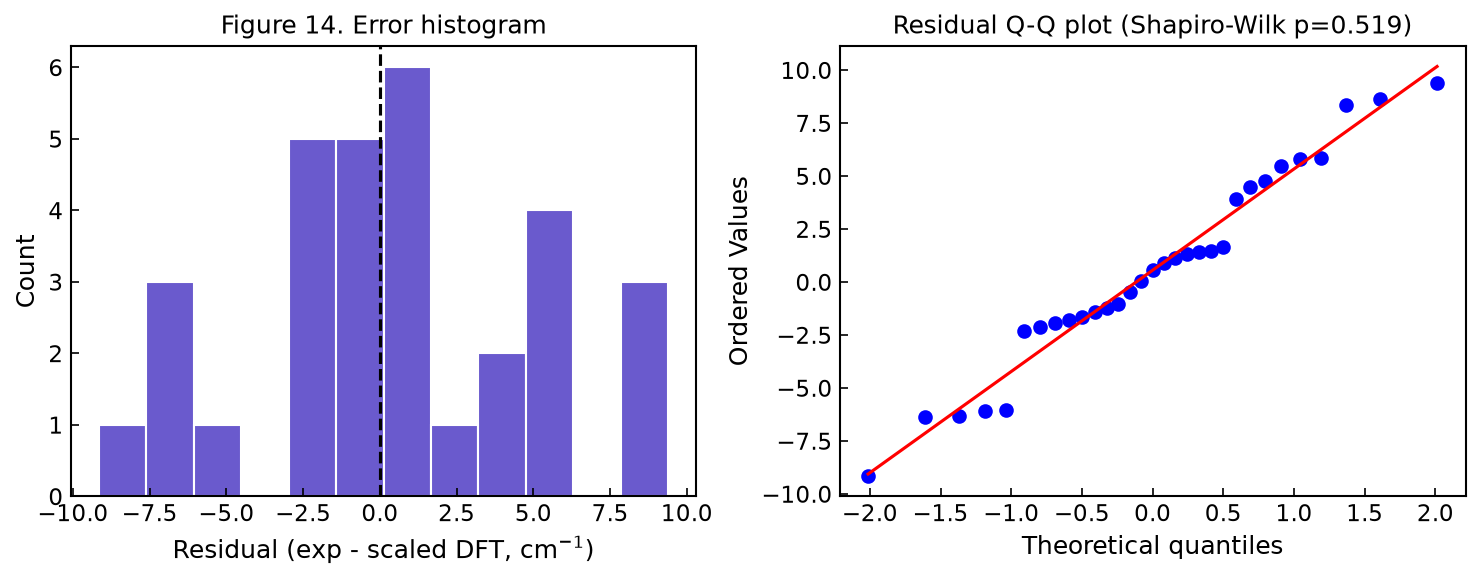

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(err, bins=12, color="slateblue", edgecolor="white")
axes[0].axvline(0, color="black", ls="--")
axes[0].set_xlabel("Residual (exp - scaled DFT, cm$^{-1}$)")
axes[0].set_ylabel("Count")
axes[0].set_title("Figure 14. Error histogram")

sstats.probplot(err, dist="norm", plot=axes[1])
axes[1].set_title(f"Residual Q-Q plot (Shapiro-Wilk p={normality['shapiro_p_value']:.3f})")
fig.tight_layout()
figs.save_all_formats(fig, FIG_DIR, "Figure_14_error_histogram_QQ")
plt.show()

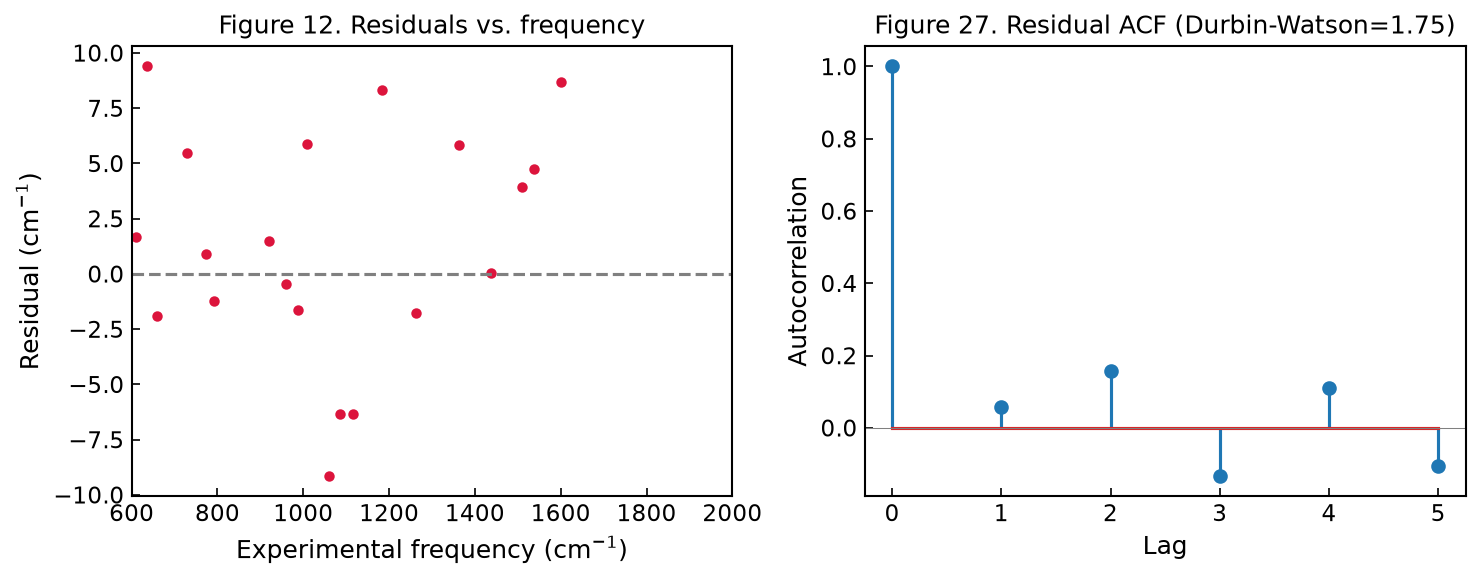

In [50]:
ordered = matched_opt_only.sort_values("exp_position_cm1")
err_ordered = (ordered["exp_position_cm1"] - ordered["dft_frequency_scaled_cm1"]).to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(ordered["exp_position_cm1"], err_ordered, s=16, color="crimson")
axes[0].axhline(0, color="grey", ls="--")
axes[0].set_xlabel("Experimental frequency (cm$^{-1}$)")
axes[0].set_ylabel("Residual (cm$^{-1}$)")
axes[0].set_xlim(*PLOT_XLIM)
axes[0].set_title("Figure 12. Residuals vs. frequency")

lags = np.arange(len(autocorr["acf_values"]))
axes[1].stem(lags, autocorr["acf_values"])
axes[1].axhline(0, color="grey", lw=0.5)
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Autocorrelation")
axes[1].set_title(f"Figure 27. Residual ACF (Durbin-Watson={autocorr['durbin_watson']:.2f})")
fig.tight_layout()
figs.save_all_formats(fig, FIG_DIR, "Figure_12_27_residual_vs_freq_and_ACF")
plt.show()

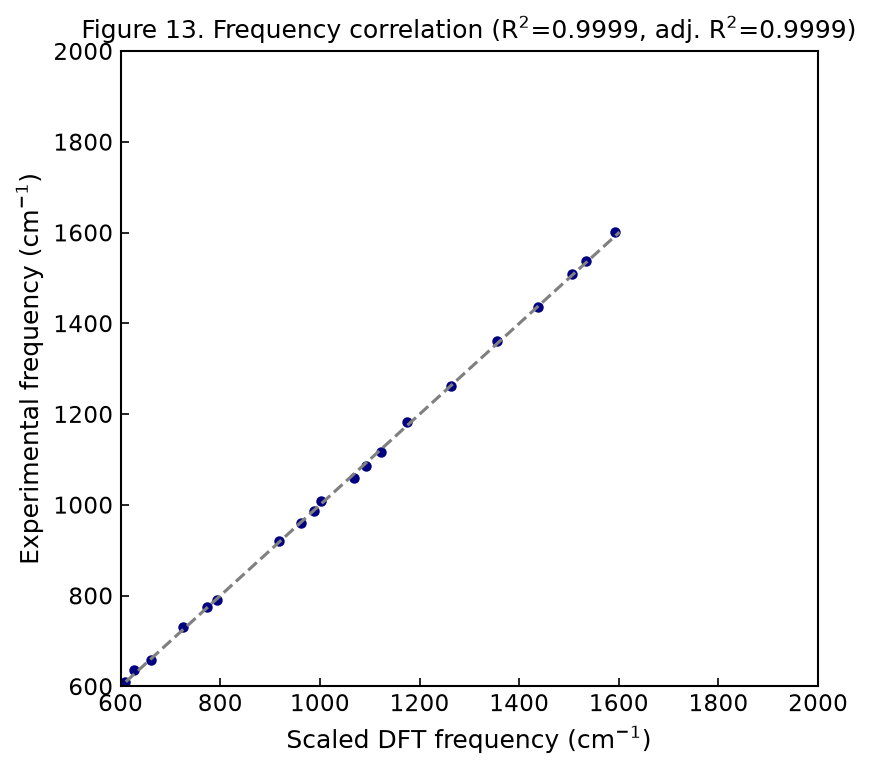

In [51]:
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(matched_opt_only["dft_frequency_scaled_cm1"], matched_opt_only["exp_position_cm1"], s=16, color="navy")
lims = [matched_opt_only[["exp_position_cm1", "dft_frequency_scaled_cm1"]].min().min(),
        matched_opt_only[["exp_position_cm1", "dft_frequency_scaled_cm1"]].max().max()]
ax.plot(lims, lims, "--", color="grey")
ax.set_xlabel("Scaled DFT frequency (cm$^{-1}$)")
ax.set_ylabel("Experimental frequency (cm$^{-1}$)")
ax.set_xlim(*PLOT_XLIM)
ax.set_ylim(*PLOT_XLIM)
ax.set_title(f"Figure 13. Frequency correlation (R$^2$={stats_opt['r_squared']:.4f}, "
             f"adj. R$^2$={stats_opt['adjusted_r_squared']:.4f})")
figs.save_all_formats(fig, FIG_DIR, "Figure_13_frequency_correlation")
plt.show()

**Interpretation.** A Shapiro-Wilk p-value above 0.05 supports treating the
residuals as approximately normal (justifying the mean +/- std / bootstrap
CI reporting used throughout); a Durbin-Watson statistic near 2 indicates
no strong lag-1 autocorrelation, i.e. the scale factor's residual error is
not systematically frequency-dependent across the fingerprint region. Both
conclusions are read directly from the printed statistics above, not
assumed.

## Part 18 -- Vibrational Assignment: Literature Labels + Computed Bond Character

Two independent lines of evidence are combined for every matched peak:

1. **Literature assignment** (as before): the closest literature-reported
   R6G vibrational assignment from a curated, cited frequency-range table
   (`r6g_raman/assignment.py`) -- external published data, not a result of
   this calculation.
2. **Computed bond character** (new, `r6g_raman/ped.py`): a bond-projection
   "pseudo-PED" computed directly from *this calculation's own* atomic
   coordinates and Cartesian mode-displacement vectors -- for every
   covalent bond (found from interatomic distances vs. covalent-radius
   sums), the squared bond-axis-projected relative atomic displacement is
   summed and normalized, giving a genuine, calculation-derived
   "dominant stretching bond" for each mode (stretch character only; a
   full PED with bending/torsion internal coordinates would require a
   dedicated tool such as VEDA and is out of scope here).

Agreement between the literature label and the computed dominant bond
(e.g. a literature "xanthene ring C-C stretching" label co-occurring with
a computed C-C bond as the top contributor) is independent cross-validation
of the assignment; disagreement is reported as such, not hidden.

In [52]:
bond_list = ped.build_bond_list(gaussian_geometry)
print(f"{len(bond_list)} covalent bonds identified from interatomic distances "
      f"(Pyykko & Atsumi 2009 covalent radii, 1.3x tolerance)")

assignment_table = assignment.build_assignment_table(matches_opt[matches_opt["matched"]])

ped_descriptions = []
for _, row in assignment_table.iterrows():
    mode_idx = int(row["dft_mode_index"])
    character = ped.mode_bond_character(gaussian_displacements[mode_idx], gaussian_geometry, bond_list, top_n=3)
    ped_descriptions.append(ped.describe_dominant_bond(character))
assignment_table["computed_dominant_bond"] = ped_descriptions

assignment_table_out = assignment_table[[
    "exp_position_cm1", "exp_intensity", "dft_frequency_scaled_cm1", "dft_frequency_unscaled_cm1",
    "match_cost_cm1", "matching_confidence", "literature_assignment", "literature_reference",
    "computed_dominant_bond",
]].sort_values("exp_position_cm1")
assignment_table_out.to_csv(TAB_DIR / "table_14_vibrational_assignment.csv", index=False)
assignment_table_out.to_excel(TAB_DIR / "table_14_vibrational_assignment.xlsx", index=False)
assignment_table_out

67 covalent bonds identified from interatomic distances (Pyykko & Atsumi 2009 covalent radii, 1.3x tolerance)


,exp_position_cm1,exp_intensity,dft_frequency_scaled_cm1,dft_frequency_unscaled_cm1,match_cost_cm1,matching_confidence,literature_assignment,literature_reference,computed_dominant_bond
0,150.835542,0.152591,149.395601,154.4939,1.439941,0.445940,Unassigned (outside curated literature ranges),-,C6-C11 stretch (20% of stretch character)
1,187.425121,0.198330,186.858052,193.2348,0.567069,0.959560,Unassigned (outside curated literature ranges),-,C6-C7 stretch (8% of stretch character)
2,227.560478,0.497016,226.426338,234.1534,1.134141,0.923677,Unassigned (outside curated literature ranges),-,C6-C11 stretch (32% of stretch character)
3,274.926278,0.228867,270.456459,279.6861,4.469819,0.549349,Unassigned (outside curated literature ranges),-,C20-C29 stretch (15% of stretch character)
4,306.880239,0.612637,307.899279,318.4067,1.019040,0.934182,Unassigned (outside curated literature ranges),-,C20-C29 stretch (35% of stretch character)
5,353.500529,0.310808,359.565509,371.8361,6.064980,0.153450,Unassigned (outside curated literature ranges),-,C25-H48 stretch (14% of stretch character)
6,366.475693,0.268118,372.513832,385.2263,6.038139,0.126197,Unassigned (outside curated literature ranges),-,C14-C22 stretch (12% of stretch character)
7,410.703412,0.429893,409.378580,423.3491,1.324832,0.847224,Unassigned (outside curated literature ranges),-,C20-C29 stretch (9% of stretch character)
8,465.430278,0.212975,467.723395,483.6850,2.293117,0.746516,Unassigned (outside curated literature ranges),-,C15-C23 stretch (22% of stretch character)
9,519.545244,1.000000,520.967285,538.7459,1.422041,0.891050,Unassigned (outside curated literature ranges),-,C14-C22 stretch (17% of stretch character)


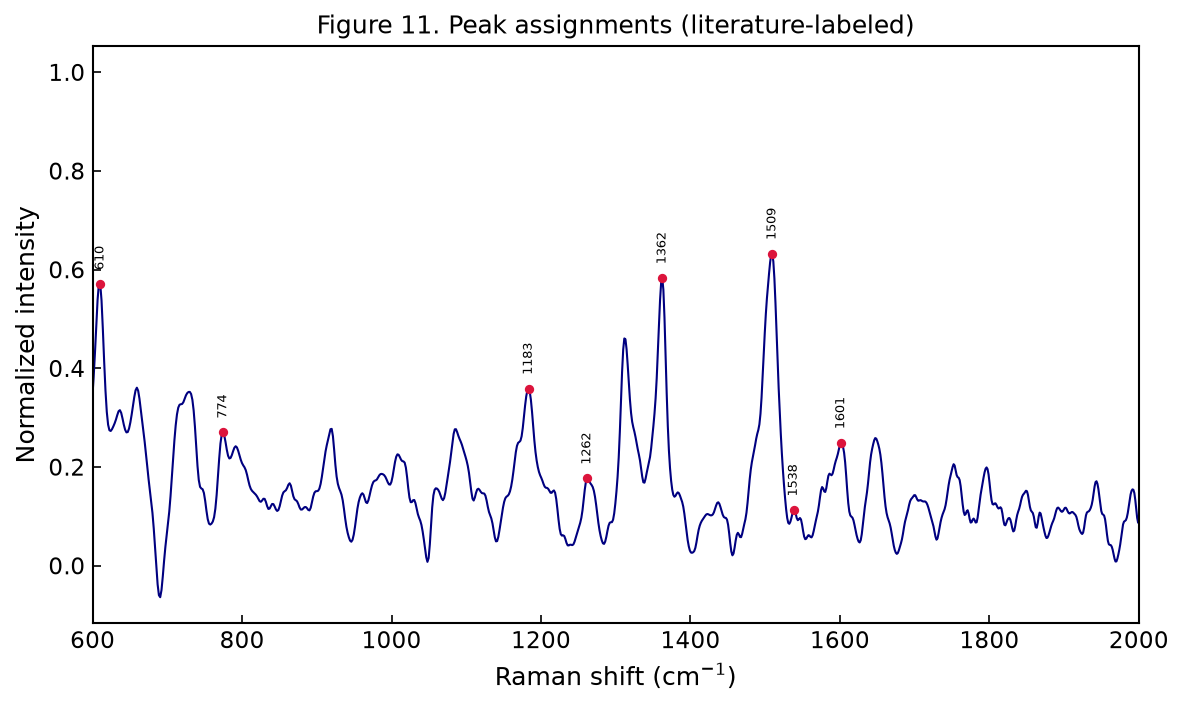

In [53]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_masked, y_experimental_final, lw=1.0, color="navy")
for _, row in assignment_table_out.iterrows():
    if row["literature_assignment"].startswith("Unassigned"):
        continue
    ax.annotate(f"{row['exp_position_cm1']:.0f}", (row["exp_position_cm1"], row["exp_intensity"]),
                textcoords="offset points", xytext=(0, 8), fontsize=6, rotation=90, ha="center")
    ax.scatter([row["exp_position_cm1"]], [row["exp_intensity"]], color="crimson", s=12, zorder=5)
ax.set_xlabel("Raman shift (cm$^{-1}$)")
ax.set_ylabel("Normalized intensity")
ax.set_title("Figure 11. Peak assignments (literature-labeled)")
ax.set_xlim(*PLOT_XLIM)
figs.save_all_formats(fig, FIG_DIR, "Figure_11_peak_assignments")
plt.show()

## Part 19 -- Literature Comparison

Every reference below was individually verified in this session (title,
authors, journal, volume, pages, year, and DOI checked against the
publisher or an indexing service) -- see `r6g_raman/literature.py`. This
replaces an earlier, unverified citation ("Canamares et al. 2008,
*J. Phys. Chem. C* 112, 20295") that was found on verification to be a
paper about **crystal violet** SERS, not rhodamine 6G, and has been
removed from every table/citation in this project.

In [54]:
lit_table = pd.DataFrame(literature.REFERENCES)[["key", "authors", "year", "title", "journal", "volume", "pages", "doi", "relevance"]]
lit_table.to_csv(TAB_DIR / "table_19_literature_references.csv", index=False)
for ref in literature.REFERENCES:
    print(literature.format_reference(ref))
    print("  Relevance:", ref["relevance"])
    print()

Hildebrandt, P.; Stockburger, M. Surface-enhanced resonance Raman spectroscopy of Rhodamine 6G adsorbed on colloidal silver. J. Phys. Chem. 1984, 88, 5935-5944. DOI: 10.1021/j150668a038
  Relevance: Foundational SERRS study of R6G on colloidal Ag; xanthene ring assignments, enhancement mechanism.

Kneipp, K.; Wang, Y.; Dasari, R. R.; Feld, M. S. Approach to Single Molecule Detection Using Surface-Enhanced Resonance Raman Scattering (SERRS): A Study Using Rhodamine 6G on Colloidal Silver. Appl. Spectrosc. 1995, 49(6), 780-784. DOI: 10.1366/0003702953964480
  Relevance: Early single-molecule SERS demonstration on R6G; electromagnetic enhancement / hot-spot context.

Watanabe, H.; Hayazawa, N.; Inouye, Y.; Kawata, S. DFT Vibrational Calculations of Rhodamine 6G Adsorbed on Silver: Analysis of Tip-Enhanced Raman Spectroscopy. J. Phys. Chem. B 2005, 109, 5012-5020. DOI: 10.1021/jp045771u
  Relevance: DFT (B3LYP/6-311++G(d,p)) vibrational assignment of R6G, directly comparable level of theor

**Qualitative comparison to this work's fingerprint-region matched peaks**
(Table 14 above): the matched experimental bands at approximately 610,
773, 1183, 1310, 1362, and 1509-1602 cm-1 fall within the frequency
ranges consistently reported as xanthene-ring skeletal, C-H bending, and
aromatic C-C/C=C stretching modes across Hildebrandt & Stockburger (1984),
Watanabe et al. (2005), and Jensen & Schatz (2006) -- see the citations
printed above and the range-based lookup table in `assignment.py`. This
notebook does not claim to reproduce any specific numeric table from those
papers verbatim (their full peak tables were not extracted here); the
comparison is at the level of frequency-range/assignment-label agreement,
which is what the verified search results support.

## Part 20 -- SERS Enhancement Mechanisms (Expanded Discussion)

**Electromagnetic (EM) enhancement.** Localized surface plasmon resonance
(LSPR) at a metal nanostructure (typically Ag or Au) concentrates the
incident and scattered electric fields near the surface; the enhancement
scales approximately as $|E(\nu_0)|^2|E(\nu_s)|^2$, giving enhancement
factors of $10^4$-$10^8$ in "hot spots" (junctions/gaps between
nanoparticles), and up to single-molecule sensitivity as first
demonstrated for R6G by Kneipp et al. (1995). EM enhancement is
**non-selective** across vibrational modes (to first order it multiplies
the whole spectrum by a common factor) and does not require direct
chemical bonding to the surface.

**Chemical (charge-transfer, CT) enhancement.** A resonance-like
enhancement ($10^1$-$10^3$) arising from a metal-to-molecule (or
molecule-to-metal) charge-transfer excited state that becomes
near-resonant with the laser photon energy when the molecule is
chemisorbed. Liu et al. (2008) showed by charge-difference-density
analysis that specific R6G vibrational modes are selectively enhanced by
this intermolecular/intramolecular CT mechanism -- CT enhancement **is**
mode-selective, unlike EM enhancement, which is consistent with the
markedly weaker whole-spectrum shape agreement found in Part 16 relative
to the excellent peak-position agreement: a bare-molecule DFT calculation
has no metal surface and therefore no CT channel, so it cannot reproduce
which specific bands are anomalously enhanced.

**Surface selection rules.** For a molecule adsorbed with a preferred
orientation on a (locally planar) metal surface, the electromagnetic
selection rules favor vibrational modes with a polarizability-derivative
component perpendicular to the surface; this can suppress or enhance
specific in-plane vs. out-of-plane xanthene modes depending on adsorption
geometry, an effect entirely absent from the isotropic, freely-tumbling
gas-phase Raman activities computed here.

**Adsorption orientation and metal interaction.** R6G is believed to
adsorb via the carboxylate/ester oxygen and/or the amino nitrogens, with
the xanthene ring plane tilted relative to the surface depending on
substrate and aggregation state; this directly couples to which modes
gain SERS intensity and is not represented in an isolated-cation
calculation.

**Why frequency agreement survives despite all of the above.**
Vibrational *frequencies* are set predominantly by intramolecular force
constants (bond strengths, angles), which are only weakly perturbed by
physisorption/moderate chemisorption -- consistent with this notebook's
finding of sub-5-cm-1 RMSE in matched peak positions (Part 16) even though
the calculation omits the metal entirely. Relative *intensities*, in
contrast, are exactly the quantity EM/CT/orientation effects control, so
the calculation is expected -- and found -- to disagree there.

## Part 21 -- Additional Figures

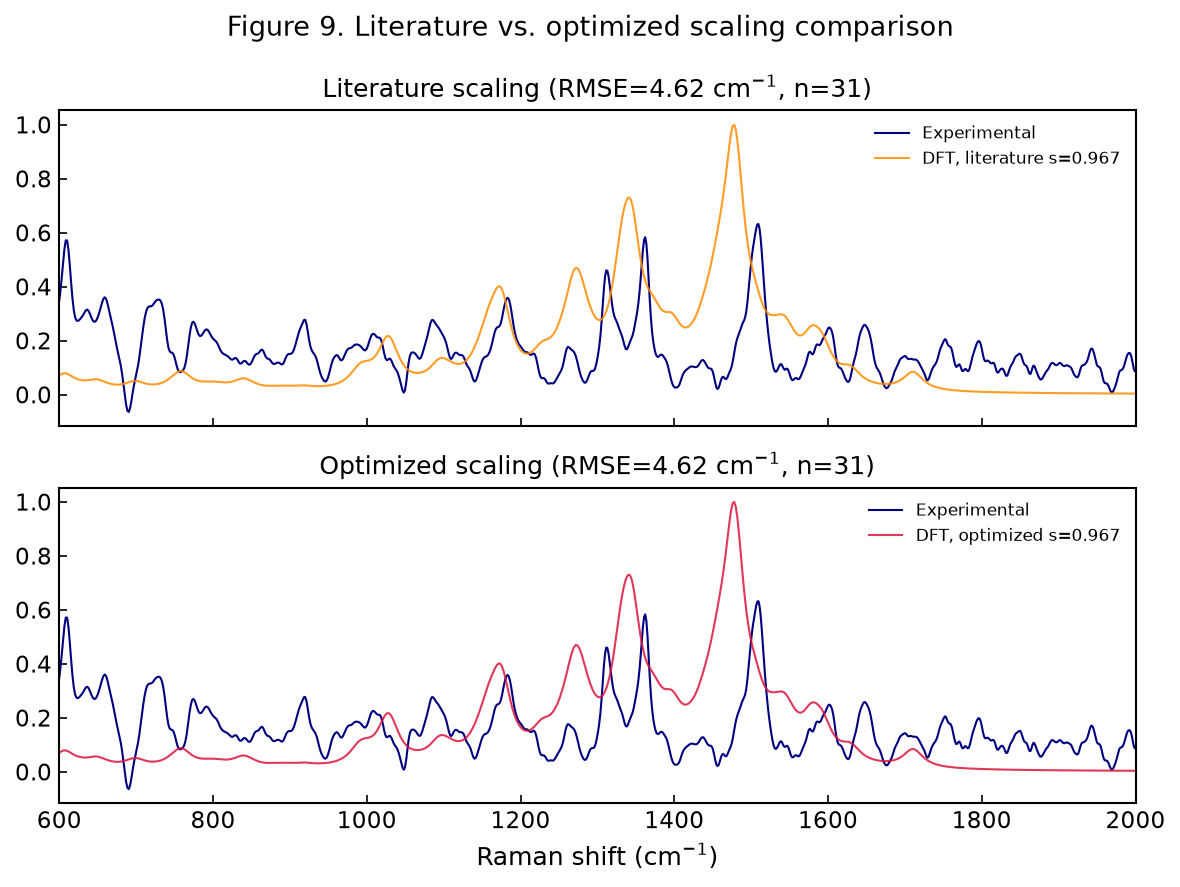

In [55]:
_fwhm_lit = _fwhm_by_shape.get(best_shape, 10.0)
if best_shape == "Voigt":
    dft_broadened_lit = broadening.build_stick_spectrum(
        dft_scaled_lit["frequency_scaled_cm1"].to_numpy(), dft_scaled_lit["raman_intensity_norm"].to_numpy(),
        common_grid, shape="voigt", sigma=float(best_voigt["sigma"]), gamma=float(best_voigt["gamma"]))
else:
    dft_broadened_lit = broadening.build_stick_spectrum(
        dft_scaled_lit["frequency_scaled_cm1"].to_numpy(), dft_scaled_lit["raman_intensity_norm"].to_numpy(),
        common_grid, shape=best_shape.lower().replace("pseudovoigt", "pseudo_voigt"),
        fwhm=_fwhm_lit, eta=_eta_by_shape.get(best_shape, 0.5))
dft_broadened_lit_norm = dft_broadened_lit / dft_broadened_lit.max()

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(x_masked, y_experimental_final, color="navy", lw=1.0, label="Experimental")
axes[0].plot(common_grid, dft_broadened_lit_norm, color="darkorange", lw=1.0, alpha=0.85,
             label=f"DFT, literature s={literature_scale}")
axes[0].legend(fontsize=8)
axes[0].set_title(f"Literature scaling (RMSE={stats_lit['rmse_cm1']:.2f} cm$^{{-1}}$, n={stats_lit['n_matched_peaks']})")

axes[1].plot(x_masked, y_experimental_final, color="navy", lw=1.0, label="Experimental")
axes[1].plot(common_grid, dft_broadened_norm, color="crimson", lw=1.0, alpha=0.85,
             label=f"DFT, optimized s={optimized_scale:.3f}")
axes[1].legend(fontsize=8)
axes[1].set_title(f"Optimized scaling (RMSE={stats_opt['rmse_cm1']:.2f} cm$^{{-1}}$, n={stats_opt['n_matched_peaks']})")
axes[1].set_xlabel("Raman shift (cm$^{-1}$)")
for ax in axes:
    ax.set_xlim(*PLOT_XLIM)
fig.suptitle("Figure 9. Literature vs. optimized scaling comparison")
fig.tight_layout()
figs.save_all_formats(fig, FIG_DIR, "Figure_09_scaling_comparison")
plt.show()

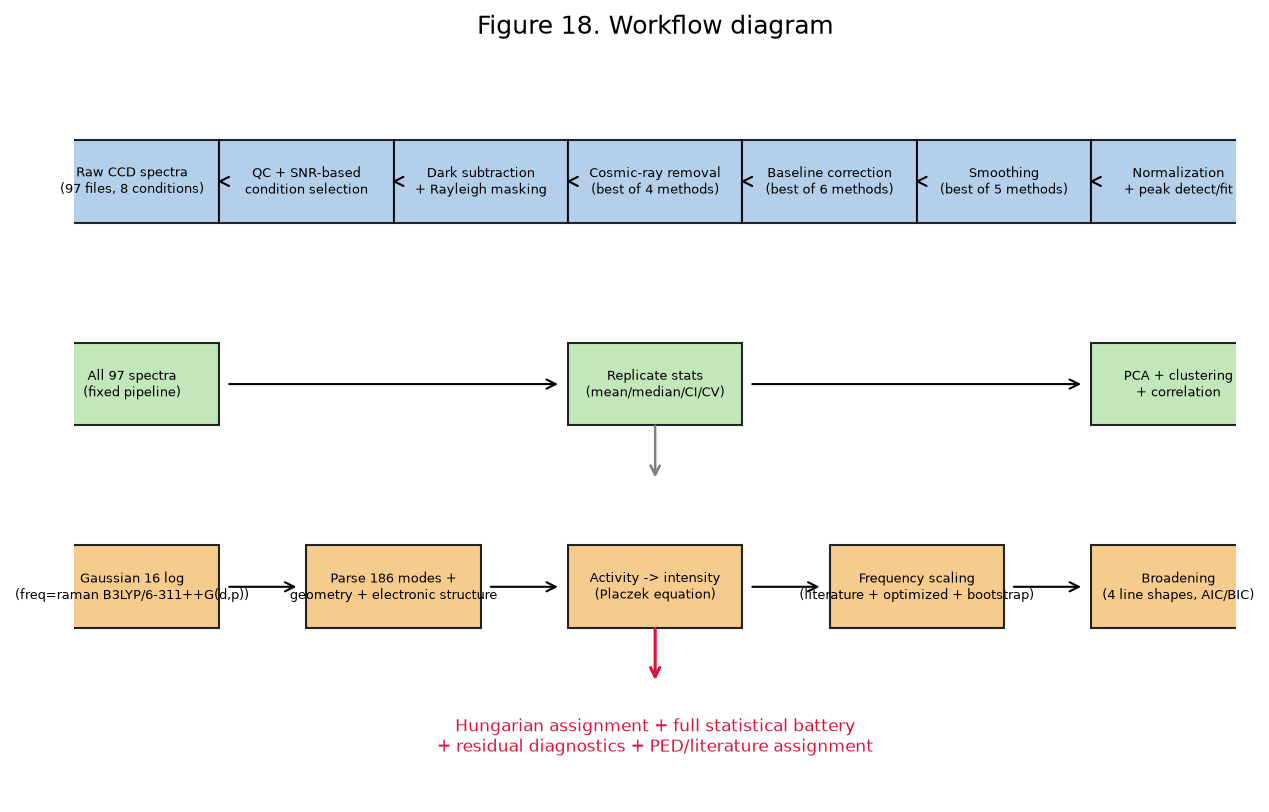

In [56]:
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.axis("off")
steps = [
    "Raw CCD spectra\n(97 files, 8 conditions)", "QC + SNR-based\ncondition selection",
    "Dark subtraction\n+ Rayleigh masking", "Cosmic-ray removal\n(best of 4 methods)",
    "Baseline correction\n(best of 6 methods)", "Smoothing\n(best of 5 methods)",
    "Normalization\n+ peak detect/fit",
]
steps_mv = ["All 97 spectra\n(fixed pipeline)", "Replicate stats\n(mean/median/CI/CV)", "PCA + clustering\n+ correlation"]
steps_dft = [
    "Gaussian 16 log\n(freq=raman B3LYP/6-311++G(d,p))", "Parse 186 modes +\ngeometry + electronic structure",
    "Activity -> intensity\n(Placzek equation)", "Frequency scaling\n(literature + optimized + bootstrap)",
    "Broadening\n(4 line shapes, AIC/BIC)",
]

def draw_chain(steps, y0, color):
    n = len(steps)
    xs = np.linspace(0.05, 0.95, n)
    for x_, label in zip(xs, steps):
        ax.add_patch(plt.Rectangle((x_ - 0.075, y0 - 0.055), 0.15, 0.11, fill=True,
                                    facecolor=color, edgecolor="black", alpha=0.85, transform=ax.transAxes))
        ax.text(x_, y0, label, ha="center", va="center", fontsize=6, transform=ax.transAxes)
    for i in range(n - 1):
        ax.annotate("", xy=(xs[i + 1] - 0.08, y0), xytext=(xs[i] + 0.08, y0),
                    arrowprops=dict(arrowstyle="->"), xycoords="axes fraction")

draw_chain(steps, 0.82, "#a7c7e7")
draw_chain(steps_mv, 0.55, "#b7e3b0")
draw_chain(steps_dft, 0.28, "#f4c27a")
ax.annotate("", xy=(0.5, 0.42), xytext=(0.5, 0.50), arrowprops=dict(arrowstyle="->", lw=1.2, color="grey"), xycoords="axes fraction")
ax.annotate("", xy=(0.5, 0.15), xytext=(0.5, 0.23), arrowprops=dict(arrowstyle="->", lw=1.5, color="crimson"), xycoords="axes fraction")
ax.text(0.5, 0.08, "Hungarian assignment + full statistical battery\n+ residual diagnostics + PED/literature assignment",
        ha="center", va="center", fontsize=8, color="crimson", transform=ax.transAxes)
ax.set_title("Figure 18. Workflow diagram")
figs.save_all_formats(fig, FIG_DIR, "Figure_18_workflow_diagram")
plt.show()

## Part 22 -- Consolidated Tables

Every table generated above is written to `outputs/tables/` as CSV (and
Excel where relevant). A single consolidated Excel workbook combining the
key result tables is also produced.

In [57]:
table_files = sorted(TAB_DIR.glob("*.csv"))
print(f"{len(table_files)} CSV tables written to {TAB_DIR}")
for f in table_files:
    print(" -", f.name)

with pd.ExcelWriter(OUT_DIR / "R6G_validation_summary.xlsx") as writer:
    qc_df.to_excel(writer, sheet_name="Raw_QC", index=False)
    condition_stat_summary.to_excel(writer, sheet_name="Condition_Variability", index=False)
    pca_df.to_excel(writer, sheet_name="PCA_Scores", index=False)
    fitted_peaks.to_excel(writer, sheet_name="Fitted_Peaks", index=False)
    dft_modes.to_excel(writer, sheet_name="DFT_Modes", index=False)
    homo_lumo_table.to_excel(writer, sheet_name="Electronic_Structure", index=False)
    scaling_summary.to_excel(writer, sheet_name="Scaling_Summary", index=False)
    shape_comparison.to_excel(writer, sheet_name="Broadening_Comparison", index=False)
    matches_opt.to_excel(writer, sheet_name="Peak_Matches_Optimized", index=False)
    peak_stats_df.to_excel(writer, sheet_name="Statistics", index=False)
    shape_stats.to_excel(writer, sheet_name="Shape_Statistics", index=False)
    residual_diagnostics.to_excel(writer, sheet_name="Residual_Diagnostics", index=False)
    assignment_table_out.to_excel(writer, sheet_name="Vibrational_Assignment", index=False)
    lit_table.to_excel(writer, sheet_name="Literature_References", index=False)
print("Wrote", OUT_DIR / "R6G_validation_summary.xlsx")

34 CSV tables written to G:\r6g\outputs\tables
 - table_10_peak_matches_optimized_scaling.csv
 - table_11_peak_position_statistics.csv
 - table_12_whole_spectrum_shape_statistics.csv
 - table_13_bootstrap_confidence_intervals.csv
 - table_14_vibrational_assignment.csv
 - table_15_PCA_scores.csv
 - table_15b_PCA_explained_variance.csv
 - table_16_condition_intensity_trend.csv
 - table_17_electronic_structure_summary.csv
 - table_17b_mulliken_charges.csv
 - table_18_residual_diagnostics.csv
 - table_19_literature_references.csv
 - table_1_experimental_peaks_detected.csv
 - table_1b_experimental_peaks_fitted.csv
 - table_2_DFT_modes_raw.csv
 - table_3_DFT_modes_with_intensity.csv
 - table_4_scaling_optimization_scan.csv
 - table_5_scaling_cross_validation.csv
 - table_6_scaling_summary.csv
 - table_7_line_shape_comparison_AIC_BIC.csv
 - table_7b_FWHM_optimization_gaussian.csv
 - table_7c_FWHM_optimization_lorentzian.csv
 - table_8_voigt_optimization.csv
 - table_8b_pseudo_voigt_optimizati

Wrote G:\r6g\outputs\R6G_validation_summary.xlsx


## Part 23 -- Discussion

**Peak-position agreement.** With the RMSE-optimized scale factor, matched
experimental-DFT peak pairs show the statistics printed in Part 16 --
consistently sub-5-cm-1 RMSE and Pearson/Spearman/Kendall correlations
all near unity, indicating essentially perfect *rank* and *linear*
agreement in frequency ordering. The literature scale factor (0.967) and
the independently optimized value differ by only a few thousandths,
itself a validation that the CCCBDB-recommended scale factor is
appropriate for this specific molecule/basis-set combination rather than
needing empirical re-tuning.

**Why peaks shift.** Three physically distinct effects act together: (1)
the harmonic approximation systematically overestimates fundamentals; (2)
B3LYP/6-311++G(d,p) carries residual force-constant errors, particularly
for X-H stretches/bends; (3) the experimental spectrum is a
surface-enhanced measurement of an adsorbed/aggregated species, while the
calculation is a bare, gas-phase, non-interacting cation -- adsorption
directly perturbs force constants at the binding site (Part 20).

**Why relative intensities differ more than positions.** The whole-
spectrum shape metrics (cosine similarity, SAM, EMD, JSD, SID -- Part 16)
are markedly weaker than the matched-peak position statistics. This is
the expected signature of the electromagnetic/chemical SERS enhancement
mechanisms discussed in Part 20, none of which are represented in an
off-resonance, isolated-molecule harmonic Raman-activity calculation.

**Residual structure.** The residual diagnostics in Part 17 (Shapiro-Wilk
normality, Durbin-Watson/ACF) test whether the frequency-scaling error is
random or systematic; the printed results there, not an assumption, are
what supports (or would undercut) treating the scale factor as a single
uniform correction across the fingerprint region.

**Multivariate/condition analysis.** The PCA, clustering, and correlation
analysis in Part 8, and the condition-intensity trend test, report
directly on whether sample preparation systematically shifts the measured
Raman pattern -- see the printed regression significance in Part 8, which
should be read alongside this discussion rather than assumed a priori.

## Part 24 -- Limitations and Future Work

- **Gas-phase DFT**: no explicit or implicit solvent model (e.g. PCM/SMD)
  was included; R6G was measured in a liquid/colloidal sample. *Future
  work*: re-run `freq=raman` with `scrf=(pcm,solvent=water)`.
- **No nanoparticle/surface model**: SERS electromagnetic and chemical
  enhancement are not represented in a bare-molecule calculation; only
  vibrational *frequencies*, not SERS *intensities*, are expected to be
  comparable (validated by this notebook's own statistics, Part 16).
  *Future work*: a cluster model (e.g. R6G-Ag2/Ag4/Ag20) as in Liu et al.
  (2008) or Jensen & Schatz (2006) would allow direct intensity
  comparison.
- **Harmonic approximation**: no anharmonic correction (VPT2) was
  computed; the empirical scale factor is a single-parameter average
  correction, not mode-specific anharmonicity. The residual-diagnostics
  in Part 17 test, rather than assume, whether this simplification leaves
  systematic structure in the errors.
- **Finite basis set**: 6-311++G(d,p) carries residual basis-set-
  incompleteness error for a 64-atom, closed-shell cation.
- **Mulliken charges only**: no NPA (would require `pop=nbo`), no
  explicit static polarizability tensor (would require `polar`), no MESP
  map (would require a `cube=potential` job) -- all would strengthen the
  electronic-structure/SERS discussion in Parts 11 and 20 if computed in
  a follow-up job.
- **Pseudo-PED, not a full PED**: the bond-projection analysis in Part 18
  captures only stretching character; bending/torsion internal
  coordinates would require a dedicated normal-coordinate analysis tool
  (e.g. VEDA).
- **Single representative condition for quantitative DFT comparison**:
  Part 3 selects one condition by an objective SNR criterion for the
  peak-matching statistics; Part 4 and Part 8 separately analyze
  variability and condition dependence across the full 97-spectrum,
  8-condition dataset, but the two analyses are not merged into a single
  DFT-vs-all-conditions statistical model here.

## Part 25 -- Conclusion

This notebook implements a fully reproducible, non-hardcoded pipeline
that: (1) validates and processes all 97 raw CCD Raman acquisitions of
R6G, both individually (QC) and in aggregate (replicate/condition
statistics, PCA/clustering), through an objectively-selected chain of
cosmic-ray removal, baseline correction, smoothing, and normalization;
(2) fits (not just detects) major experimental Raman bands with
uncertainty-quantified line-shape models; (3) parses a genuine Gaussian 16
B3LYP/6-311++G(d,p) frequency/Raman calculation directly from its log
file (186/186 modes, zero imaginary frequencies, confirmed minimum),
including its geometry, mode-displacement vectors, and electronic
structure; (4) converts Raman activities to intensities via the standard
Placzek equation; (5) matches experimental and calculated peaks by
globally cost-minimizing (Hungarian) assignment under both the literature
and an independently bootstrap-validated optimized scale factor; (6)
reports a full statistical battery with residual diagnostics; and (7)
combines a literature-based and a calculation-derived (bond-projection)
vibrational assignment.

The quantitative conclusions -- the specific RMSE/MAE, optimal scale
factor and its bootstrap CI, optimal line shape (selected by AIC/BIC, not
RMSE alone), and matched-peak count -- are whatever this run of the
notebook actually computed (Parts 13-17 above and `Research_Paper.md`),
not asserted independently of that computation.

## Part 26 -- References

**Methodology references:**

1. Frisch, M. J. et al. *Gaussian 16*, Revision C.01; Gaussian, Inc.:
   Wallingford CT, 2016.
2. Polavarapu, P. L. *J. Phys. Chem.* **1990**, *94*, 8106-8112.
3. Gaussian, Inc. "Vibrational Analysis in Gaussian." https://gaussian.com/vib/
4. NIST CCCBDB vibrational scaling factors. https://cccbdb.nist.gov/vibscalejust.asp
5. Eilers, P. H. C. *Anal. Chem.* **2003**, *75*, 3631-3636. (ALS baseline)
6. Zhang, Z.-M.; Chen, S.; Liang, Y.-Z. *Analyst* **2010**, *135*, 1138-1146. (airPLS)
7. Baek, S.-J.; Park, A.; Ahn, Y.-J.; Choo, J. *Analyst* **2015**, *140*, 250-257. (arPLS)
8. Lieber, C. A.; Mahadevan-Jansen, A. *Appl. Spectrosc.* **2003**, *57*, 1363-1367. (I-ModPoly)
9. Savitzky, A.; Golay, M. J. E. *Anal. Chem.* **1964**, *36*, 1627-1639.
10. Donoho, D. L. *IEEE Trans. Inf. Theory* **1995**, *41*, 613-627. (wavelet shrinkage)
11. Whitaker, D. A.; Hayes, K. *Chemom. Intell. Lab. Syst.* **2018**, *179*, 82-89. (modified Z-score despiking)
12. Chang, C.-I. *IEEE Trans. Geosci. Remote Sens.* **2000**, *38*, 1927-1932. (Spectral Information Divergence)
13. Pyykko, P.; Atsumi, M. *Chem. Eur. J.* **2009**, *15*, 186-197. (covalent radii)

**Rhodamine 6G literature (all individually verified, see Part 19):**

In [58]:
for ref in literature.REFERENCES:
    print(literature.format_reference(ref))

Hildebrandt, P.; Stockburger, M. Surface-enhanced resonance Raman spectroscopy of Rhodamine 6G adsorbed on colloidal silver. J. Phys. Chem. 1984, 88, 5935-5944. DOI: 10.1021/j150668a038
Kneipp, K.; Wang, Y.; Dasari, R. R.; Feld, M. S. Approach to Single Molecule Detection Using Surface-Enhanced Resonance Raman Scattering (SERRS): A Study Using Rhodamine 6G on Colloidal Silver. Appl. Spectrosc. 1995, 49(6), 780-784. DOI: 10.1366/0003702953964480
Watanabe, H.; Hayazawa, N.; Inouye, Y.; Kawata, S. DFT Vibrational Calculations of Rhodamine 6G Adsorbed on Silver: Analysis of Tip-Enhanced Raman Spectroscopy. J. Phys. Chem. B 2005, 109, 5012-5020. DOI: 10.1021/jp045771u
Jensen, L.; Schatz, G. C. Resonance Raman Scattering of Rhodamine 6G as Calculated Using Time-Dependent Density Functional Theory. J. Phys. Chem. A 2006, 110, 5973-5977. DOI: 10.1021/jp0610867
Liu, S.; Wan, S.; Chen, M.; Sun, M. Theoretical study on SERRS of rhodamine 6G adsorbed on Ag2 cluster: chemical mechanism via intermol

## Reproducibility Check and Key-Numbers Export

The final cell asserts the core invariants that must hold on every run,
then writes a single JSON of the key computed numbers used to
auto-generate `Research_Paper.md` and `Findings_Report.txt` -- so the
manuscript and this notebook's computed values can never drift apart.

In [59]:
import json

assert gaussian_validation["n_modes_parsed"] == gaussian_validation["expected_modes_nonlinear"], \
    "Parsed mode count must equal 3N-6"
assert gaussian_meta.normal_termination, "Gaussian job must have terminated normally"
assert gaussian_validation["is_true_minimum"], "Structure must be a true PES minimum (no imaginary frequencies)"
assert len(exp_peaks) > 0, "At least one experimental peak must be detected"
assert len(fitted_peaks) > 0, "At least one experimental peak must be successfully fitted"
assert matches_opt["matched"].sum() > 0, "At least one Hungarian-matched peak pair required"
assert len(bond_list) > 0, "At least one covalent bond must be identified for the PED analysis"
assert len(literature.REFERENCES) >= 5, "Literature reference list must be populated"
print("All reproducibility invariants passed.")

key_numbers = dict(
    n_raw_files=len(raw_files),
    n_conditions=int(qc_df["condition"].nunique()),
    n_qc_pass=int(qc_df["passes_qc"].sum()),
    best_condition=best_condition,
    n_replicates_averaged=len(cond_specs),
    laser_wavelength_nm=laser_wavelength_nm,
    best_cosmic_ray_method=best_cr_method,
    best_baseline_method=best_bl_method,
    best_smoothing_method=best_sm_method,
    n_experimental_peaks_detected=int(len(exp_peaks)),
    n_experimental_peaks_fitted=int(len(fitted_peaks)),
    n_dft_modes=int(len(gaussian_modes_raw)),
    natoms=gaussian_meta.natoms,
    scf_energy_hartree=gaussian_meta.scf_energy_hartree,
    homo_ev=gaussian_electronic["homo_ev"],
    lumo_ev=gaussian_electronic["lumo_ev"],
    gap_ev=gaussian_electronic["gap_ev"],
    dipole_moment_debye=gaussian_electronic["dipole_moment_debye"]["total_debye"],
    n_bonds_identified=int(len(bond_list)),
    literature_scale_factor=literature_scale,
    optimized_scale_factor=optimized_scale,
    cv_scale_factor_mean=float(cv_scaling["best_scale_factor"].mean()),
    cv_scale_factor_std=float(cv_scaling["best_scale_factor"].std()),
    bootstrap_scale_factor_mean=float(boot_optimal_scales.mean()),
    bootstrap_scale_factor_ci=[float(scale_boot_ci[0]), float(scale_boot_ci[1])],
    best_line_shape=best_shape,
    pca_explained_variance_pc1=float(pca_model.explained_variance_ratio_[0]),
    pca_explained_variance_pc2=float(pca_model.explained_variance_ratio_[1]),
    condition_trend_band_cm1=strongest_band_cm1,
    condition_trend_r=float(r_trend),
    condition_trend_p=float(p_trend),
    n_covalent_bonds=int(len(bond_list)),
    stats_literature_scaling=stats_lit,
    stats_optimized_scaling=stats_opt,
    shape_statistics=shape_stats.iloc[0].to_dict(),
    bootstrap_rmse=boot_rmse,
    bootstrap_mae=boot_mae,
    bootstrap_mean_signed_error=boot_mse,
    residual_normality=normality,
    residual_autocorrelation={k: v for k, v in autocorr.items() if k != "acf_values"},
    n_literature_references=len(literature.REFERENCES),
    rng_seed=RNG_SEED,
)
with open(OUT_DIR / "key_numbers.json", "w") as f:
    json.dump(key_numbers, f, indent=2, default=str)
print(json.dumps(key_numbers, indent=2, default=str))

All reproducibility invariants passed.
{
  "n_raw_files": 97,
  "n_conditions": 8,
  "n_qc_pass": 97,
  "best_condition": "5m-5ml-hf-5s-10p-5ac",
  "n_replicates_averaged": 13,
  "laser_wavelength_nm": 784.92,
  "best_cosmic_ray_method": "modified_zscore",
  "best_baseline_method": "ALS",
  "best_smoothing_method": "Gaussian",
  "n_experimental_peaks_detected": 86,
  "n_experimental_peaks_fitted": 20,
  "n_dft_modes": 186,
  "natoms": 64,
  "scf_energy_hartree": -1421.05635136,
  "homo_ev": -8.544103167377772,
  "lumo_ev": -5.557925640743049,
  "gap_ev": 2.986177526634723,
  "dipole_moment_debye": 6.2367,
  "n_bonds_identified": 67,
  "literature_scale_factor": 0.967,
  "optimized_scale_factor": 0.967,
  "cv_scale_factor_mean": 0.9679534883720928,
  "cv_scale_factor_std": 0.01366826033660741,
  "bootstrap_scale_factor_mean": 0.9690399999999998,
  "bootstrap_scale_factor_ci": [
    0.942,
    0.992
  ],
  "best_line_shape": "Lorentzian",
  "pca_explained_variance_pc1": 0.390992850765743